# Parameter Estimation for State-Space Models

This notebook covers parameter estimation for state-space models using two complementary approaches:

- **Maximum Likelihood Estimation (MLE)** via the Kalman filter log-likelihood (exact, only for linear Gaussian models)
- **Metropolis-Hastings (MH)** using the exact closed-form log-likelihood — exact posterior, no particle noise
- **Particle Marginal Metropolis-Hastings (PMMH)** using the particle filter log-likelihood as an unbiased estimator of the marginal likelihood (applicable to any SSM)

Sections:
1. MLE for `SimpleLinearGaussianSSM` — closed-form Kalman log-likelihood + numerical optimization
2. Bayesian posterior inference for `SimpleLinearGaussianSSM`
    - 2.1 Metropolis-Hastings via exact Kalman log-likelihood
    - 2.2 PMMH via particle filter log-likelihood
3. Compare PMMH and BlockedPMMH
4. Effect of `N_particles` on PMMH — variance, bias, and the `alpha·sigma` identification issue
    - discuss how to set threshold on log-likelihood variance to choose `N_particles`, also could reference `testing_estimation.ipynb` results
5. Effect of observation noise `τ` on parameter recoverability
6. Model misspecification — fitting a Gaussian SSM to t-distributed or ARMA data
7. Compare (naive and blocked) PMMH, Kim filter MLE, (naive and blocked) RBPF PMMH for regime-switching models

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.linear_gaussian import SimpleLinearGaussianSSM, LinearGaussianSSM
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM
from estimation.particle_filter import ParticleFilter
from estimation.kalman_filter import KalmanFilter
from estimation.resampling_methods import SystematicResampling
from estimation.metropolis_hastings import MetropolisHastings, BlockMetropolisHastings
from estimation.pmmh import PMMH, BlockPMMH
from estimation.mle_estimator import MLEEstimator
from estimation.kde import KDE
from utils import rmse, chain_ess

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── shared helpers ────────────────────────────────────────────────────────────

def log_constrained_params_prior(theta_con):
    # phi    ~ Cauchy(0, 1) truncated to (-1, 1)  [∝ 2/(1 + phi^2)]
    # alpha  ~ N(0, 1)
    # sigma2 ~ HalfCauchy(0, 1)  (∝ 1/sigma2)
    # tau2   ~ HalfCauchy(0, 1)  (∝ 1/tau2)
    if theta_con[0] < -1 or theta_con[0] > 1:
        return -np.inf
    if theta_con[2] < 0 or theta_con[3] < 0:
        return -np.inf
    return np.sum([
        np.log(2) - np.log(1 + theta_con[0] ** 2),
        -0.5 * theta_con[1] ** 2,
        -np.log(theta_con[2]),
        -np.log(theta_con[3]),
        ])

def log_prior(theta_con):
    return log_constrained_params_prior(theta_con)


---
## 1. MLE via Kalman filter log-likelihood

For `SimpleLinearGaussianSSM` the marginal log-likelihood $\log p(y_{1:T} \mid \theta)$ is analytically
tractable via the Kalman filter recursion (implemented in `model.log_likelihood(y)`).
We can therefore find the MLE by maximizing over the parameter vector $\theta = (\phi, \alpha, \sigma, \tau)$
using `scipy.optimize.minimize`.

Parameters are transformed to an unconstrained space via `model.unconstrain_params` (e.g. `tanh` for
$\phi$, `log` for positive scale parameters) before optimization, then mapped back with
`model.constrain_params`.

We compare MLE estimates against:
- the **true generating parameters**
- the **profile log-likelihood** surface to visualize identifiability

T=300  conditional log p(y|x*,θ*)=-411.06
True params: {'phi': 0.9, 'alpha': 1.0, 'sigma2': 0.25, 'tau2': 1.0}


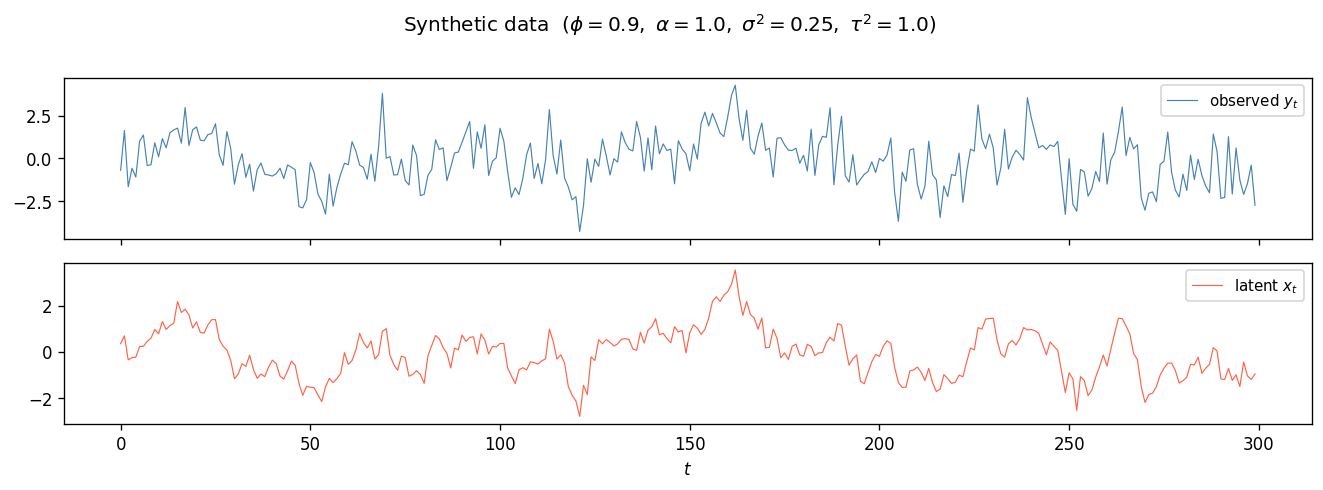

In [2]:
# ── true parameters and synthetic dataset ─────────────────────────────────────
TRUE_PARAMS = dict(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0)
T    = 300
SEED = 42

model = SimpleLinearGaussianSSM(**TRUE_PARAMS, seed=SEED)
states_raw, obs_raw, cond_loglik = model.generate_data(T)
states = states_raw.ravel()   # (T,)
obs    = obs_raw.ravel()      # (T,)

print(f"T={T}  conditional log p(y|x*,θ*)={float(cond_loglik):.2f}")
print(f"True params: {TRUE_PARAMS}")

fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
axes[0].plot(obs,    lw=0.7, color='steelblue', label='observed $y_t$')
axes[1].plot(states, lw=0.7, color='tomato',    label='latent $x_t$')
for ax in axes:
    ax.legend(loc='upper right', fontsize=9)
axes[1].set_xlabel('$t$')
fig.suptitle(
    r'Synthetic data  ($\phi=0.9,\ \alpha=1.0,\ \sigma^2=0.25,\ \tau^2=1.0$)',
    y=1.01,
)
plt.tight_layout()
plt.show()


In [3]:
# ── MLE via MLEEstimator ──────────────────────────────────────────────────────
# MLEEstimator maximizes model.log_likelihood(data) using scipy.optimize.minimize
# (L-BFGS-B by default).  Optimization happens in the *unconstrained* parameter
# space (atanh φ, α, log σ, log τ) so no box constraints are needed; results
# are mapped back to the constrained space in MLEResult.constrained_params.
#
# n_restarts=3: the best optimum over 3 random restarts is returned, which helps
# avoid local optima that can appear with highly persistent AR processes.

mle = MLEEstimator(model, obs, n_restarts=3, restart_std=0.3, seed=0)
result = mle.fit()
mle.compute_std_errors()   # numerical Hessian + delta method → fills result.std_errors

print(result.summary())

Restart 0/3 best val: 495.5196729164321
Restart 1/3 best val: 495.5196729164287
Restart 2/3 best val: 495.5196729164287
MLEEstimator.fit  0.132s
MLEResult  loglik=-495.5197  converged  n_evals=65
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.852314      0.053785
  alpha                 1.040965    108.018733
  sigma2                0.314403     65.253037
  tau2                  0.975979      0.145880


Param         True         MLE          SE   |bias|/SE
────────────────────────────────────────────────────
phi         0.9000      0.8523      0.0538        0.89
alpha       1.0000      1.0410    108.0187        0.00
sigma2      0.2500      0.3144     65.2530        0.00
tau2        1.0000      0.9760      0.1459        0.16


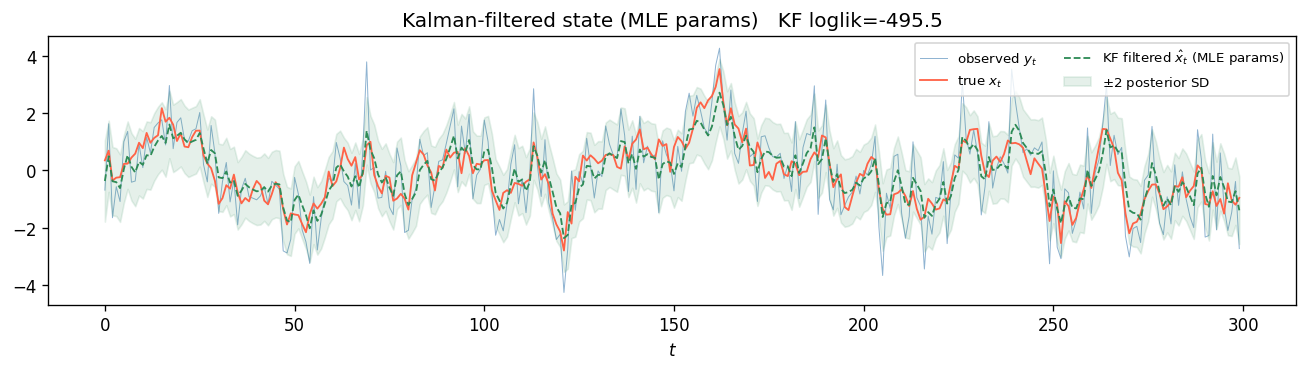

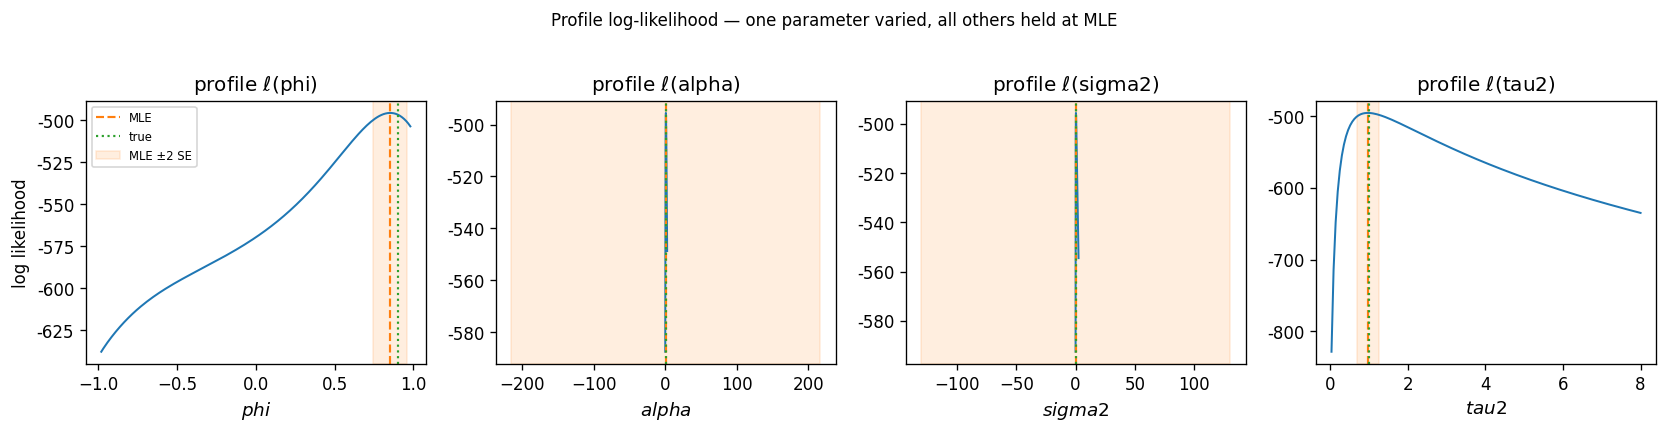

In [4]:
# ── comparison table and plots ────────────────────────────────────────────────
names   = result.param_names                  # ['phi', 'alpha', 'sigma2', 'tau2']
mle_est = list(result.constrained_params)
ses     = list(result.std_errors) if result.std_errors is not None else [None] * 4
trues   = [TRUE_PARAMS[p] for p in names]

print(f"{'Param':<8}  {'True':>8}  {'MLE':>10}  {'SE':>10}  {'|bias|/SE':>10}")
print("─" * 52)
for name, tv, mv, se in zip(names, trues, mle_est, ses):
    if se is not None and not np.isnan(se) and se > 0:
        print(f"{name:<8}  {tv:>8.4f}  {mv:>10.4f}  {se:>10.4f}  {abs(mv-tv)/se:>10.2f}")
    else:
        print(f"{name:<8}  {tv:>8.4f}  {mv:>10.4f}  {'—':>10}  {'—':>10}")

# ── Kalman filter with MLE params → filtered state ────────────────────────────
phi_m, alpha_m, sigma2_m, tau2_m = mle_est
lg_mle = LinearGaussianSSM(
    a=np.array([[phi_m]]),
    c=np.array([[alpha_m]]),
    q=np.array([[sigma2_m]]),
    r=np.array([[tau2_m]]),
)
kf_mle = KalmanFilter(lg_mle, obs)
filt_means, filt_covs, kf_loglik = kf_mle.run_filter()
filt_std = np.sqrt(filt_covs[:, 0, 0])

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(obs,    lw=0.6, color='steelblue', alpha=0.6, label='observed $y_t$', zorder=1)
ax.plot(states, lw=1.1, color='tomato',    label='true $x_t$',                zorder=2)
ax.plot(filt_means[:, 0], lw=1.1, color='seagreen', ls='--',
        label=r'KF filtered $\hat{x}_t$ (MLE params)', zorder=3)
ax.fill_between(range(T),
                filt_means[:, 0] - 2 * filt_std,
                filt_means[:, 0] + 2 * filt_std,
                color='seagreen', alpha=0.12, label=r'$\pm$2 posterior SD')
ax.set_xlabel('$t$')
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_title(f'Kalman-filtered state (MLE params)   KF loglik={kf_loglik:.1f}')
plt.tight_layout()
plt.show()

# ── profile log-likelihoods (1-D slices through MLE) ─────────────────────────
grids = {
    'phi':    np.linspace(-0.98, 0.98, 150),
    'alpha':  np.linspace(0.15, 2.80, 150),
    'sigma2': np.linspace(0.005, 2.5,  150),
    'tau2':   np.linspace(0.04,  8.0,  150),
}
mle_dict = dict(zip(names, mle_est))

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, name in zip(axes, names):
    lls = []
    for v in grids[name]:
        kwargs = {**mle_dict, name: v}
        try:
            m_tmp = SimpleLinearGaussianSSM(**kwargs)
            lls.append(m_tmp.log_likelihood(obs))
        except (ValueError, FloatingPointError):
            lls.append(np.nan)
    lls = np.array(lls)

    ax.plot(grids[name], lls, lw=1.2, color='C0')
    ax.axvline(mle_dict[name],    color='C1', ls='--', lw=1.3, label='MLE')
    ax.axvline(TRUE_PARAMS[name], color='C2', ls=':',  lw=1.3, label='true')

    idx = names.index(name)
    se  = ses[idx]
    if se is not None and not np.isnan(se) and se > 0:
        ax.axvspan(mle_dict[name] - 2*se, mle_dict[name] + 2*se,
                   alpha=0.13, color='C1', label='MLE ±2 SE')

    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(f'profile $\\ell$({name})')
    if name == names[0]:
        ax.set_ylabel('log likelihood')
        ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

plt.suptitle('Profile log-likelihood — one parameter varied, all others held at MLE',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()


---
## 2.1 Metropolis-Hastings via exact log-likelihood

For `SimpleLinearGaussianSSM` the marginal log-likelihood $\log p(y_{1:T} \mid \theta)$ is
available in closed form via the Kalman filter recursion.  `MetropolisHastings` exploits this
to run *exact* random-walk MH — acceptance decisions use the true log-likelihood with no
particle noise.

The sampler targets the change-of-variables posterior in unconstrained space:

$$\pi(z) \propto p(y \mid \theta(z)) \cdot p_\text{prior}(\theta(z)) \cdot |\!\det J(z)|$$

where $z$ is the unconstrained parameter vector, $\theta(z) = \texttt{constrain\_params}(z)$,
and $J(z) = d\theta/dz$ is the Jacobian of the reparameterisation.  The Jacobian does **not**
cancel in the acceptance ratio because $J(z_\text{prop}) \neq J(z_\text{curr})$ for nonlinear
transforms (tanh, exp).  Both terms are computed automatically by `_log_prior_and_jac`.

We warm-start from the MLE optimum (Section 1) and use the same synthetic dataset, so that
posteriors can be directly compared to MLE point estimates and their asymptotic standard errors.
Section 2.2 replaces the exact log-likelihood with a particle filter estimate (PMMH) and shows
the effect of particle noise on mixing and posterior width.

In [5]:
# ── MH setup ──────────────────────────────────────────────────────────────────
N_ITER_MH = 3000
BURN_IN_MH = 500
step_mh   = np.array([0.06, 0.10, 0.12, 0.12])   # (phi, alpha, log σ², log τ²)

model_mh  = SimpleLinearGaussianSSM(**TRUE_PARAMS, seed=13)
theta0_mh = result.unconstrained_params   # warm start from MLE

mh = MetropolisHastings(model_mh, obs, n_iter=N_ITER_MH,
                        step_sizes=step_mh, theta0=theta0_mh,
                        log_prior=log_prior, seed=1)
print(repr(mh))


MetropolisHastings(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0), n_iter=3000)


In [6]:
print("Running Metropolis-Hastings (exact Kalman log-likelihood, 3000 iterations) ...")
chain_mh, ll_mh, acc_mh = mh.run()

constrained_mh = model_mh.constrain_chain(chain_mh[BURN_IN_MH:])

mh.summary(burn=BURN_IN_MH)

print(f"\n{'Param':<8}  {'True':>8}  {'Post mean':>10}  {'Post std':>10}  {'ESS':>8}")
print("─" * 52)
for k, name in enumerate(model_mh.params_dict.keys()):
    samp = constrained_mh[:, k]
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{samp.mean():>10.4f}  {samp.std():>10.4f}  {chain_ess(samp):>8.1f}")

Running Metropolis-Hastings (exact Kalman log-likelihood, 3000 iterations) ...
MetropolisHastings.run  2.267s
param              mean        std
----------------------------------
phi              0.8414     0.0543
alpha            1.3498     0.5526
sigma2           0.3346     0.3323
tau2             0.9604     0.1520

Acceptance rate: 0.523  (burn=500)

Param         True   Post mean    Post std       ESS
────────────────────────────────────────────────────
phi         0.9000      0.8414      0.0543      33.1
alpha       1.0000      1.3498      0.5526       8.3
sigma2      0.2500      0.3346      0.3323       7.9
tau2        1.0000      0.9604      0.1520      78.0


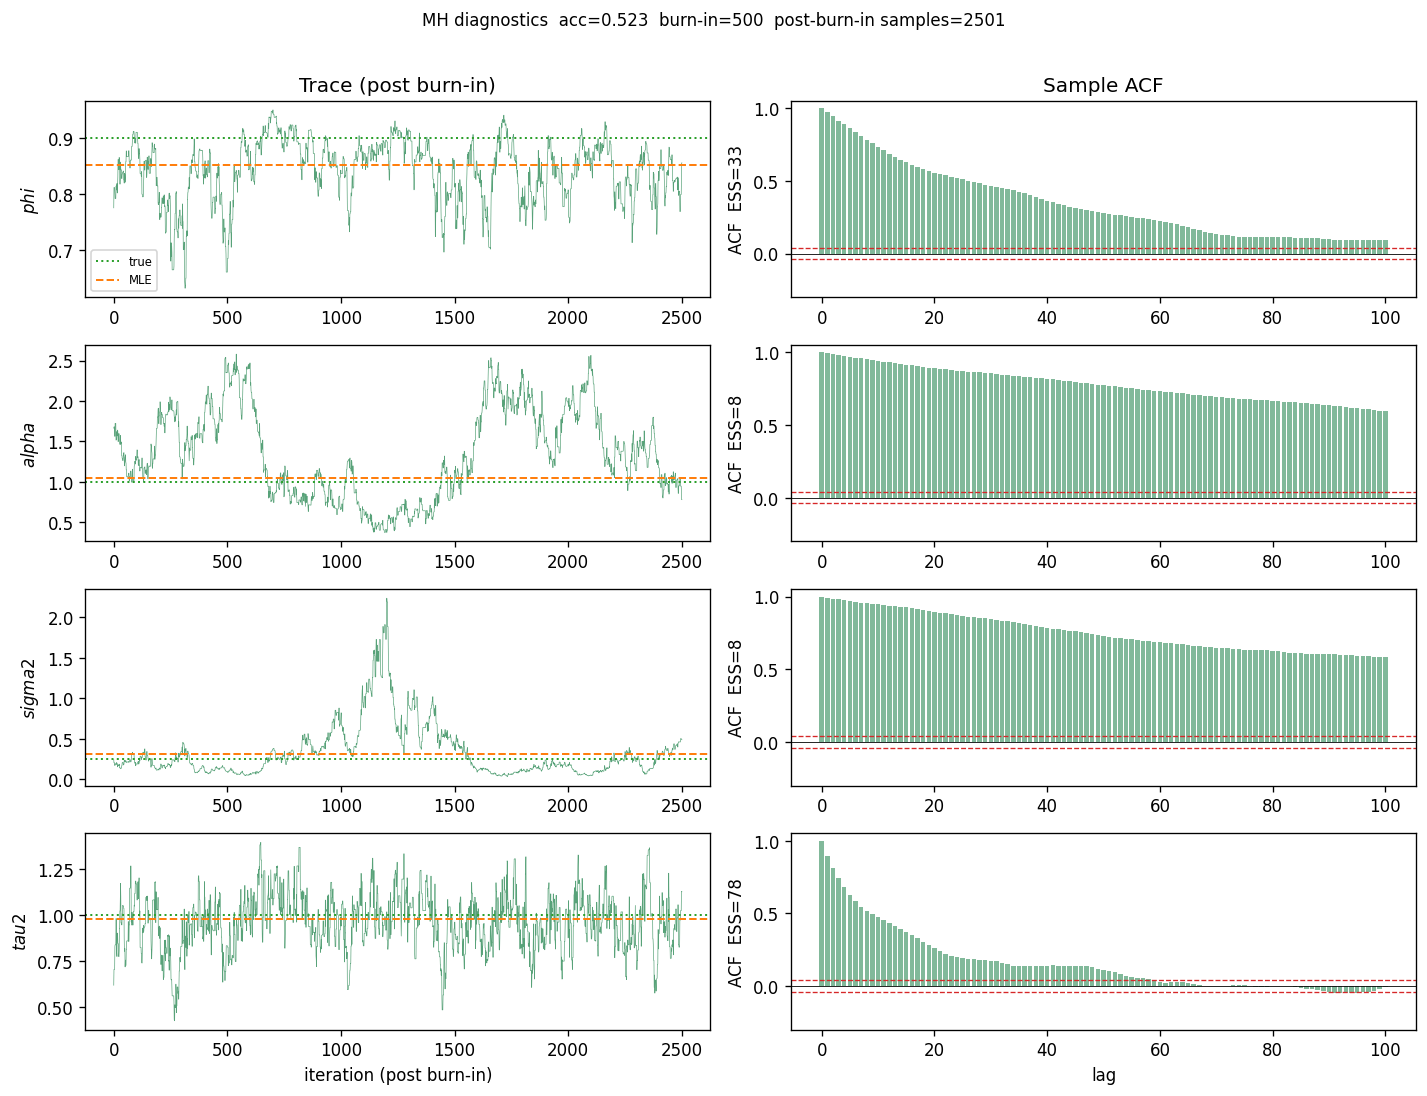

In [7]:
names_mh = list(model_mh.params_dict.keys())
fig, axes = plt.subplots(4, 2, figsize=(12, 9))

for k, name in enumerate(names_mh):
    samp = constrained_mh[:, k]
    tv   = TRUE_PARAMS[name]
    mv   = list(result.constrained_params)[k]

    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='seagreen', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2)
    ax_t.axhline(mv, color='C1', ls='--', lw=1.2)
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.plot([], [], color='C2', ls=':', lw=1.2, label='true')
        ax_t.plot([], [], color='C1', ls='--', lw=1.2, label='MLE')
        ax_t.legend(fontsize=7)

    ax_a = axes[k, 1]
    n_s  = len(samp)
    max_lag = min(100, n_s - 1)
    xc  = samp - samp.mean()
    var = xc.var()
    acf = np.correlate(xc, xc, 'full')[n_s - 1:] / (n_s * var) if var > 1e-15 else np.zeros(n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1], width=0.8, color='seagreen', alpha=0.6)
    ax_a.axhline(0, color='k', lw=0.5)
    ci = 1.96 / np.sqrt(n_s)
    ax_a.axhline( ci, color='C3', ls='--', lw=0.8)
    ax_a.axhline(-ci, color='C3', ls='--', lw=0.8)
    ax_a.set_ylim(-0.3, 1.05)
    ax_a.set_ylabel(f'ACF  ESS={chain_ess(samp):.0f}')
    if k == 0:
        ax_a.set_title('Sample ACF')

axes[-1, 0].set_xlabel('iteration (post burn-in)')
axes[-1, 1].set_xlabel('lag')
plt.suptitle(
    f'MH diagnostics  acc={acc_mh.mean():.3f}  '
    f'burn-in={BURN_IN_MH}  post-burn-in samples={len(constrained_mh)}',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()

Note that alpha and sigma have very low ESS due to weak identifiability issue.

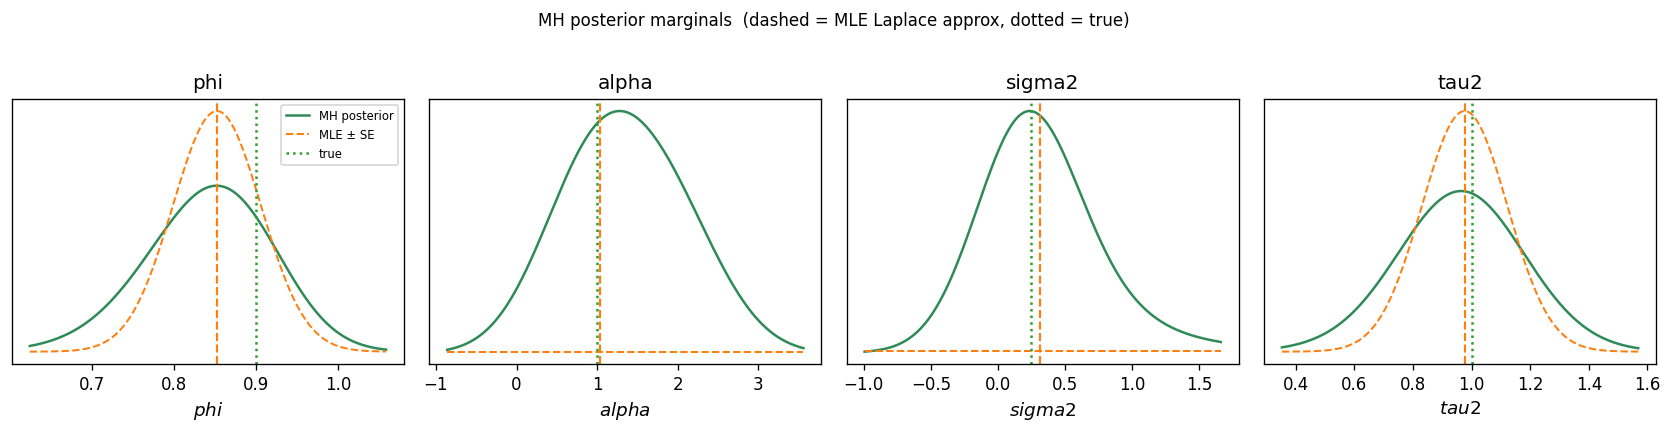

In [8]:
from scipy.stats import norm as _sp_norm

names_mh    = list(model_mh.params_dict.keys())
con_list_mh = list(result.constrained_params)
se_list_mh  = list(result.std_errors) if result.std_errors is not None else [None] * 4

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for k, (ax, name) in enumerate(zip(axes, names_mh)):
    samp = constrained_mh[:, k]
    tv   = TRUE_PARAMS[name]
    mv   = con_list_mh[k]
    se   = se_list_mh[k]

    kde = KDE(samp)
    lo  = samp.mean() - 4 * samp.std()
    hi  = samp.mean() + 4 * samp.std()
    xg  = np.linspace(lo, hi, 400)
    ax.plot(xg, kde.evaluate(xg), lw=1.5, color='seagreen', label='MH posterior')

    if se is not None and not np.isnan(se) and se > 0:
        ax.plot(xg, _sp_norm.pdf(xg, mv, se), lw=1.2, ls='--', color='C1',
                label='MLE ± SE')

    ax.axvline(tv, color='C2', ls=':', lw=1.5, label='true')
    ax.axvline(mv, color='C1', ls='--', lw=1.3)
    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(name)
    ax.set_yticks([])
    if k == 0:
        ax.legend(fontsize=7)

plt.suptitle('MH posterior marginals  (dashed = MLE Laplace approx, dotted = true)',
             y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

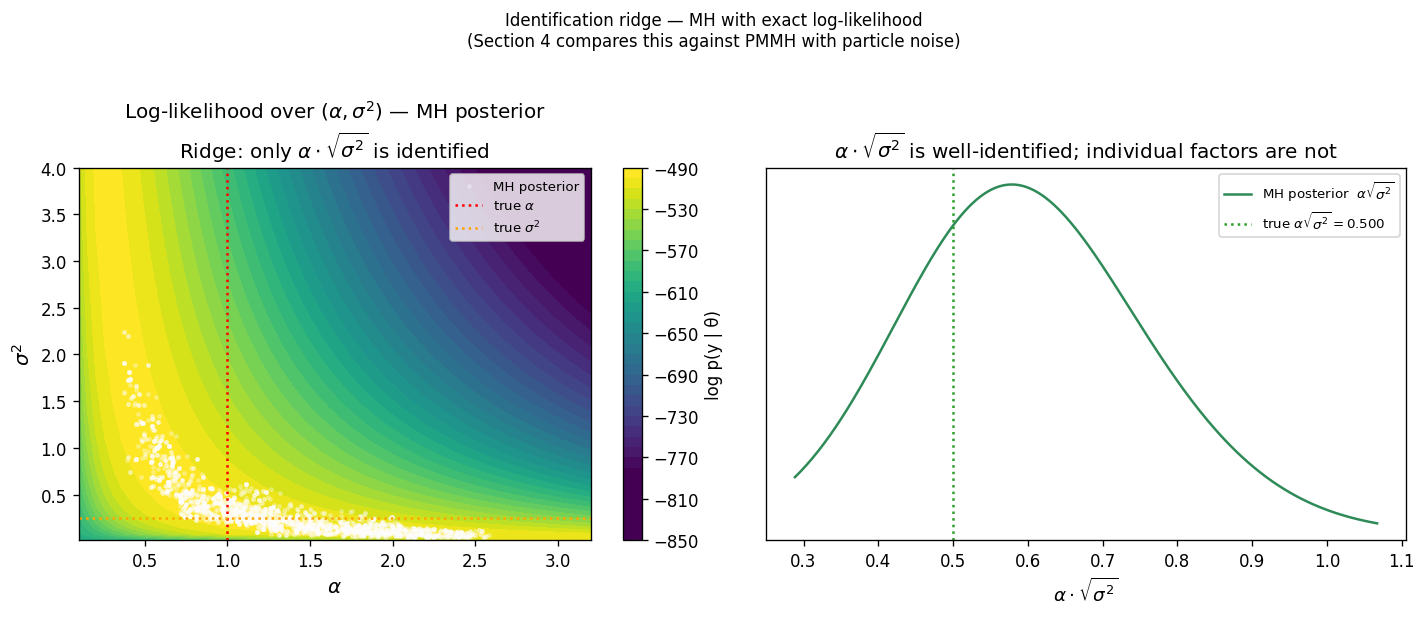

In [9]:
# ── α·σ² identification ridge in the MH posterior ────────────────────────────
# Compute the 2-D Kalman log-likelihood over (alpha, sigma2) with phi, tau2
# fixed at their true values, then overlay the MH samples to show the chain
# traces the ridge.  (The ridge is α·sqrt(σ²) = const in variance space.)
phi_fix      = TRUE_PARAMS["phi"]
tau2_fix     = TRUE_PARAMS["tau2"]
n_grid_ridge = 60

alpha_g  = np.linspace(0.1, 3.2, n_grid_ridge)
sigma2_g = np.linspace(0.01, 4.0, n_grid_ridge)
AA_mh, SS_mh = np.meshgrid(alpha_g, sigma2_g)
LL_mh = np.full_like(AA_mh, np.nan)

for i in range(n_grid_ridge):
    for j in range(n_grid_ridge):
        try:
            m_tmp = SimpleLinearGaussianSSM(phi_fix, AA_mh[i, j], SS_mh[i, j], tau2_fix)
            LL_mh[i, j] = m_tmp.log_likelihood(obs)
        except (ValueError, FloatingPointError):
            pass

alpha_samp  = constrained_mh[:, 1]   # alpha column
sigma2_samp = constrained_mh[:, 2]   # sigma2 column
prod_true   = TRUE_PARAMS["alpha"] * np.sqrt(TRUE_PARAMS["sigma2"])
prod_mh     = alpha_samp * np.sqrt(sigma2_samp)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
vmin_r = np.nanpercentile(LL_mh, 5)
cf = ax.contourf(AA_mh, SS_mh, LL_mh, levels=40, cmap="viridis",
                 vmin=vmin_r, vmax=np.nanmax(LL_mh))
plt.colorbar(cf, ax=ax, label="log p(y | θ)")
ax.scatter(alpha_samp, sigma2_samp, c="white", s=4, alpha=0.25,
           label="MH posterior", rasterized=True)
ax.axvline(TRUE_PARAMS["alpha"],  color="red",    ls=":", lw=1.5, label=r"true $\alpha$")
ax.axhline(TRUE_PARAMS["sigma2"], color="orange", ls=":", lw=1.5, label=r"true $\sigma^2$")
ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_ylabel(r"$\sigma^2$", fontsize=12)
ax.set_title(
    r"Log-likelihood over $(\alpha, \sigma^2)$ — MH posterior" "\n"
    r"Ridge: only $\alpha \cdot \sqrt{\sigma^2}$ is identified"
)
ax.legend(fontsize=8)

ax2 = axes[1]
kde_prod = KDE(prod_mh)
xg = np.linspace(max(0.0, prod_mh.min() - 0.05), prod_mh.max() + 0.05, 300)
ax2.plot(xg, kde_prod.evaluate(xg), lw=1.5, color="seagreen",
         label=r"MH posterior  $\alpha\sqrt{\sigma^2}$")
ax2.axvline(prod_true, color="C2", ls=":", lw=1.5,
            label=fr"true $\alpha\sqrt{{\sigma^2}} = {prod_true:.3f}$")
ax2.set_xlabel(r"$\alpha \cdot \sqrt{\sigma^2}$", fontsize=11)
ax2.set_title(r"$\alpha \cdot \sqrt{\sigma^2}$ is well-identified; individual factors are not")
ax2.legend(fontsize=8)
ax2.set_yticks([])

plt.suptitle(
    r"Identification ridge — MH with exact log-likelihood" "\n"
    r"(Section 4 compares this against PMMH with particle noise)",
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()


---

# 2.1.2 Metropolis Hastings with fixed alpha
Due to the non-identifiability of the alpha·sigma ridge, here we fix alpha = 1 and estimate the other three parameters using MH.

In [10]:
# ── 2.1.2 — FixedAlphaSSM: alpha fixed at 1.0, estimate (phi, sigma2, tau2) ──
# Fixing alpha breaks the alpha·sqrt(sigma2) ridge and makes the posterior
# identifiable.  Parameters are now (phi, sigma2, tau2) with variance params.

class FixedAlphaSSM(SimpleLinearGaussianSSM):
    """SimpleLinearGaussianSSM with alpha fixed at 1; estimates (phi, sigma2, tau2)."""
    ALPHA_FIXED = 1.0

    def __init__(self, phi, sigma2, tau2, seed=None):
        super().__init__(phi=phi, alpha=self.ALPHA_FIXED, sigma2=sigma2, tau2=tau2, seed=seed)
        self.params_dict = {'phi': phi, 'sigma2': sigma2, 'tau2': tau2}

    def update_params(self, constrained_params):
        phi, sigma2, tau2 = constrained_params
        SimpleLinearGaussianSSM.update_params(self, [phi, self.ALPHA_FIXED, sigma2, tau2])
        self.params_dict = {'phi': phi, 'sigma2': sigma2, 'tau2': tau2}

    def unconstrain_params(self, constrained_params):
        phi, sigma2, tau2 = constrained_params
        return np.array([np.arctanh(phi), np.log(sigma2), np.log(tau2)])

    def constrain_params(self, unconstrained_params):
        u_phi, u_sigma2, u_tau2 = unconstrained_params
        return [float(np.tanh(u_phi)), float(np.exp(u_sigma2)), float(np.exp(u_tau2))]

    def jacobian_constrain_params(self, unconstrained_params):
        u_phi, u_sigma2, u_tau2 = unconstrained_params
        return np.diag([
            1.0 - np.tanh(u_phi) ** 2,
            np.exp(u_sigma2),
            np.exp(u_tau2),
        ])


def log_prior_fixed_alpha(theta_con):
    """Independent priors on (phi, sigma2, tau2) with alpha fixed."""
    phi, sigma2, tau2 = theta_con
    if phi <= -1 or phi >= 1:
        return -np.inf
    if sigma2 <= 0 or tau2 <= 0:
        return -np.inf
    return sum([
        np.log(2) - np.log(1 + phi ** 2),   # Cauchy(0,1) on (-1,1) for phi
        -np.log(sigma2),                      # HalfCauchy(0,1) ∝ 1/sigma2
        -np.log(tau2),                        # HalfCauchy(0,1) ∝ 1/tau2
    ])


N_ITER_FA  = 3000
BURN_IN_FA = 500

model_fa  = FixedAlphaSSM(phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                           tau2=TRUE_PARAMS['tau2'], seed=5)
theta0_fa = model_fa.unconstrain_params(
    [TRUE_PARAMS['phi'], TRUE_PARAMS['sigma2'], TRUE_PARAMS['tau2']]
)

mh_fa = MetropolisHastings(
    model_fa, obs,
    n_iter=N_ITER_FA,
    step_sizes=np.array([0.06, 0.12, 0.12]),
    theta0=theta0_fa,
    log_prior=log_prior_fixed_alpha,
    seed=3,
)
print(mh_fa)


MetropolisHastings(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0), n_iter=3000)


In [11]:
print("Running MH with fixed alpha=1.0 (3000 iterations) ...")
chain_fa, ll_fa, acc_fa = mh_fa.run()

constrained_fa = model_fa.constrain_chain(chain_fa[BURN_IN_FA:])

mh_fa.summary(burn=BURN_IN_FA)

names_fa   = list(model_fa.params_dict.keys())
true_fa    = [TRUE_PARAMS[p] for p in names_fa]

print(f"\n{'Param':<8}  {'True':>8}  {'Post mean':>10}  {'Post std':>10}  {'ESS':>8}")
print("─" * 52)
for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    print(f"{name:<8}  {true_fa[k]:>8.4f}  "
          f"{samp.mean():>10.4f}  {samp.std():>10.4f}  {chain_ess(samp):>8.1f}")


Running MH with fixed alpha=1.0 (3000 iterations) ...
MetropolisHastings.run  2.406s
param              mean        std
----------------------------------
phi              0.8349     0.0614
sigma2           0.4049     0.1615
tau2             0.9373     0.1527

Acceptance rate: 0.582  (burn=500)

Param         True   Post mean    Post std       ESS
────────────────────────────────────────────────────
phi         0.9000      0.8349      0.0614      34.0
sigma2      0.2500      0.4049      0.1615      27.3
tau2        1.0000      0.9373      0.1527      44.4


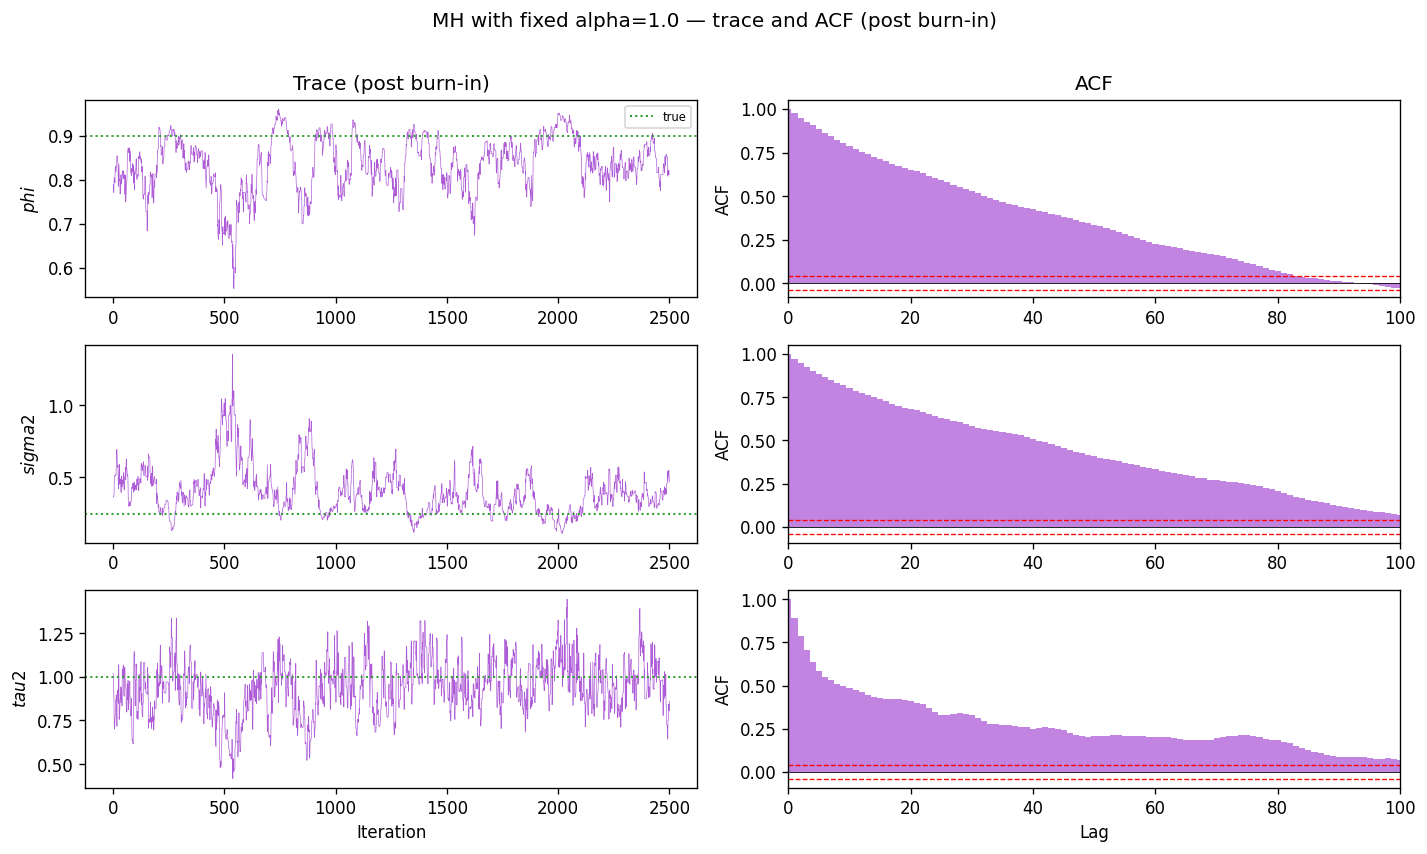

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(12, 7))

for k, name in enumerate(names_fa):
    samp = constrained_fa[:, k]
    tv   = TRUE_PARAMS[name]

    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='darkorchid', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2, label='true')
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.legend(fontsize=7)

    ax_a = axes[k, 1]
    n_s     = len(samp)
    max_lag = min(100, n_s - 1)
    xc      = samp - samp.mean()
    var     = xc.var()
    acf     = np.correlate(xc, xc, mode='full')[n_s - 1:] / (var * n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1],
             width=1.0, color='darkorchid', alpha=0.6)
    ax_a.axhline(0,  color='black', lw=0.5)
    ax_a.axhline( 1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.axhline(-1.96 / np.sqrt(n_s), color='red', ls='--', lw=0.8)
    ax_a.set_xlim(0, max_lag)
    ax_a.set_ylabel('ACF')
    if k == 0:
        ax_a.set_title('ACF')

axes[-1, 0].set_xlabel('Iteration')
axes[-1, 1].set_xlabel('Lag')
plt.suptitle('MH with fixed alpha=1.0 — trace and ACF (post burn-in)', y=1.01)
plt.tight_layout()
plt.show()


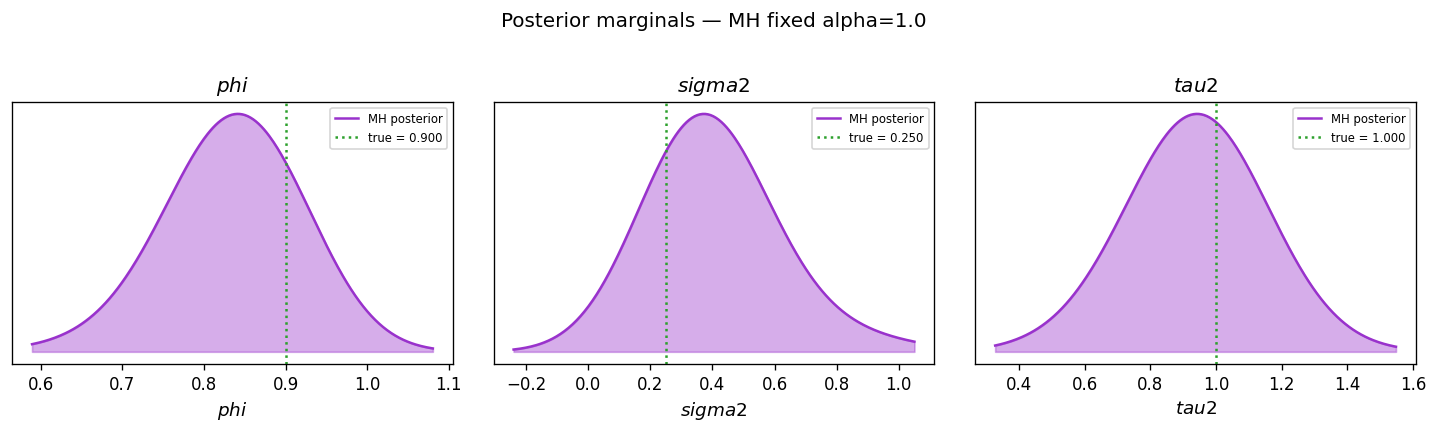

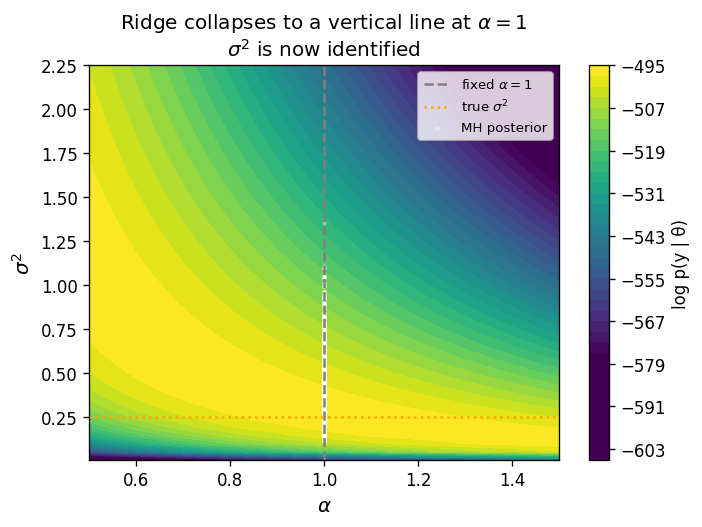

In [13]:
# ── Posterior KDEs and the collapsed ridge ────────────────────────────────────
from scipy.stats import norm as _sp_norm

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for k, (ax, name) in enumerate(zip(axes, names_fa)):
    samp = constrained_fa[:, k]
    tv   = TRUE_PARAMS[name]

    kde = KDE(samp)
    lo  = samp.mean() - 4 * samp.std()
    hi  = samp.mean() + 4 * samp.std()
    xg  = np.linspace(lo, hi, 300)
    ax.fill_between(xg, kde.evaluate(xg), alpha=0.4, color='darkorchid')
    ax.plot(xg, kde.evaluate(xg), lw=1.5, color='darkorchid', label='MH posterior')
    ax.axvline(tv, color='C2', ls=':', lw=1.5, label=f'true = {tv:.3f}')
    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(f'${name}$')
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.suptitle('Posterior marginals — MH fixed alpha=1.0', y=1.02)
plt.tight_layout()
plt.show()

# ── Residual alpha·sigma2 scatter to confirm ridge is gone ────────────────────
phi_fix_fa  = TRUE_PARAMS['phi']
tau2_fix_fa = TRUE_PARAMS['tau2']
n_grid_fa   = 50

alpha_gfa  = np.linspace(0.5, 1.5, n_grid_fa)
sigma2_gfa = np.linspace(0.01, 2.25, n_grid_fa)
AA_fa, SS_fa = np.meshgrid(alpha_gfa, sigma2_gfa)
LL_fa = np.full_like(AA_fa, np.nan)

for i in range(n_grid_fa):
    for j in range(n_grid_fa):
        try:
            m_tmp = SimpleLinearGaussianSSM(phi_fix_fa, AA_fa[i, j], SS_fa[i, j], tau2_fix_fa)
            LL_fa[i, j] = m_tmp.log_likelihood(obs)
        except (ValueError, FloatingPointError):
            pass

sigma2_samp_fa = constrained_fa[:, 1]  # sigma2 column (phi=0, sigma2=1, tau2=2)

fig, ax = plt.subplots(figsize=(6, 4.5))
vmin_fa = np.nanpercentile(LL_fa, 5)
cf = ax.contourf(AA_fa, SS_fa, LL_fa, levels=40, cmap='viridis',
                 vmin=vmin_fa, vmax=np.nanmax(LL_fa))
plt.colorbar(cf, ax=ax, label='log p(y | θ)')
ax.axvline(1.0,                  color='grey',   ls='--', lw=1.5, label=r'fixed $\alpha=1$')
ax.axhline(TRUE_PARAMS['sigma2'], color='orange', ls=':',  lw=1.5, label=r'true $\sigma^2$')
ax.scatter([1.0] * len(sigma2_samp_fa), sigma2_samp_fa,
           c='white', s=3, alpha=0.25, rasterized=True, label='MH posterior')
ax.set_xlabel(r'$\alpha$', fontsize=12)
ax.set_ylabel(r'$\sigma^2$', fontsize=12)
ax.set_title(
    r'Ridge collapses to a vertical line at $\alpha=1$' '\n'
    r'$\sigma^2$ is now identified'
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


---
## 2.2 PMMH parameter estimation — alpha fixed at true value

Particle Marginal Metropolis-Hastings replaces the intractable marginal likelihood
$p(y_{1:T} \mid \theta)$ with the particle filter's unbiased estimator $\hat{p}_N(y_{1:T} \mid \theta)$.
The resulting chain targets the exact posterior $p(\theta \mid y_{1:T})$ for any fixed $N$.

To avoid the $\alpha \cdot \sqrt{\sigma^2}$ identification ridge (Section 2.1.2), we fix $\alpha$
at its true value $\alpha=1.0$ and estimate $(\phi, \sigma^2, \tau^2)$ — the same setup as
the MH section above, but using the PF log-likelihood estimate instead of the exact Kalman one.

Setup:
- **Model**: `FixedAlphaSSM` — $\alpha$ fixed, estimates $(\phi, \sigma^2, \tau^2)$
- **Prior**: `log_prior_fixed_alpha` on $(\phi, \sigma^2, \tau^2)$
- **Proposal**: Gaussian random walk in the unconstrained space
- **Likelihood**: PF log-likelihood from `ParticleFilter.run_filter()`


In [ ]:
theta_exact_mh_mean = {
    "phi": 0.8349,
    "sigma2": 0.4049,
    "tau2": 0.9373,
}

theta_true = {
    "phi": 0.9,
    "sigma2": 0.25,
    "tau2": 1.0,
}

def check_pf_vs_kalman(theta, obs, N_vals=(100, 500, 1000, 5000), R=30):
    model_k = FixedAlphaSSM(**theta)
    kal = model_k.log_likelihood(obs)

    print("theta:", theta)
    print("Kalman loglik:", kal)

    for N in N_vals:
        vals = []
        for seed in range(R):
            model_pf = FixedAlphaSSM(**theta, seed=seed)
            pf = ParticleFilter(model_pf, N, obs, SystematicResampling(seed=seed))
            *_, ll = pf.run_filter(verbose=False)
            vals.append(ll)

        vals = np.array(vals)
        print(
            f"N={N:5d}",
            f"PF mean={vals.mean():.3f}",
            f"PF sd={vals.std(ddof=1):.3f}",
            f"bias={vals.mean() - kal:.3f}",
        )

check_pf_vs_kalman(theta_true, obs)
check_pf_vs_kalman(theta_exact_mh_mean, obs)

theta: {'phi': 0.9, 'sigma2': 0.25, 'tau2': 1.0}
Kalman loglik: -496.1442961836118
ParticleFilter.run_filter  0.213s
ParticleFilter.run_filter  0.232s
ParticleFilter.run_filter  0.232s
ParticleFilter.run_filter  0.210s
ParticleFilter.run_filter  0.233s
ParticleFilter.run_filter  0.214s
ParticleFilter.run_filter  0.229s
ParticleFilter.run_filter  0.218s
ParticleFilter.run_filter  0.221s
ParticleFilter.run_filter  0.231s
ParticleFilter.run_filter  0.225s
ParticleFilter.run_filter  0.218s
ParticleFilter.run_filter  0.212s
ParticleFilter.run_filter  0.216s
ParticleFilter.run_filter  0.208s
ParticleFilter.run_filter  0.217s
ParticleFilter.run_filter  0.208s
ParticleFilter.run_filter  0.220s
ParticleFilter.run_filter  0.212s
ParticleFilter.run_filter  0.222s
ParticleFilter.run_filter  0.207s
ParticleFilter.run_filter  0.222s
ParticleFilter.run_filter  0.213s
ParticleFilter.run_filter  0.227s
ParticleFilter.run_filter  0.226s
ParticleFilter.run_filter  0.213s
ParticleFilter.run_filter  0.232s

In [ ]:
# ── PMMH with alpha fixed at true value ───────────────────────────────────────
# FixedAlphaSSM fixes alpha = 1.0 = TRUE_PARAMS['alpha']; estimates (phi, sigma2, tau2).
N_ITER_2   = 3000
N_PART_2   = 1000
BURN_IN_2  = 500
step_2     = np.array([0.06, 0.12, 0.12])   # unconstrained steps: (atanh φ, log σ², log τ²)

model_2  = FixedAlphaSSM(phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                          tau2=TRUE_PARAMS['tau2'], seed=7)
theta0_2 = model_2.unconstrain_params(
    [TRUE_PARAMS['phi'], TRUE_PARAMS['sigma2'], TRUE_PARAMS['tau2']]
)

pf_2    = ParticleFilter(model_2, N_PART_2, obs, SystematicResampling(seed=3))
pmmh_2  = PMMH(model_2, pf_2, n_iter=N_ITER_2,
               step_sizes=step_2, theta0=theta0_2,
               log_prior=log_prior_fixed_alpha, seed=5)
print(repr(pmmh_2))


PMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0), n_iter=3000, N_particles=1000)


In [ ]:
print("Running PMMH (N=1000 particles, 3000 iterations, alpha fixed=1.0) ...")
chain_2, ll_2, acc_2 = pmmh_2.run()
print(f"Acceptance rate: {acc_2.mean():.3f}")

constrained_2 = model_2.constrain_chain(chain_2[BURN_IN_2:])

print(f"\n{'Param':<8}  {'True':>8}  {'Post mean':>10}  {'Post std':>10}  {'ESS':>8}")
print("─" * 52)
for k, name in enumerate(model_2.params_dict.keys()):
    samp = constrained_2[:, k]
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{samp.mean():>10.4f}  {samp.std():>10.4f}  {chain_ess(samp):>8.1f}")


Running PMMH (N=1000 particles, 3000 iterations, alpha fixed=1.0) ...
ParticleFilter.run_filter  2.121s
ParticleFilter.run_filter  2.003s
ParticleFilter.run_filter  2.065s
ParticleFilter.run_filter  2.042s
ParticleFilter.run_filter  2.082s
ParticleFilter.run_filter  2.003s
ParticleFilter.run_filter  2.063s
ParticleFilter.run_filter  2.008s
ParticleFilter.run_filter  2.015s
ParticleFilter.run_filter  2.055s
ParticleFilter.run_filter  2.014s
ParticleFilter.run_filter  2.047s
ParticleFilter.run_filter  2.095s
ParticleFilter.run_filter  2.021s
ParticleFilter.run_filter  2.105s
ParticleFilter.run_filter  2.010s
ParticleFilter.run_filter  2.089s
ParticleFilter.run_filter  1.984s
ParticleFilter.run_filter  2.005s
ParticleFilter.run_filter  2.026s
ParticleFilter.run_filter  2.063s
ParticleFilter.run_filter  2.000s
ParticleFilter.run_filter  2.155s
ParticleFilter.run_filter  2.157s
ParticleFilter.run_filter  2.147s
ParticleFilter.run_filter  2.055s
ParticleFilter.run_filter  2.081s
ParticleFilt

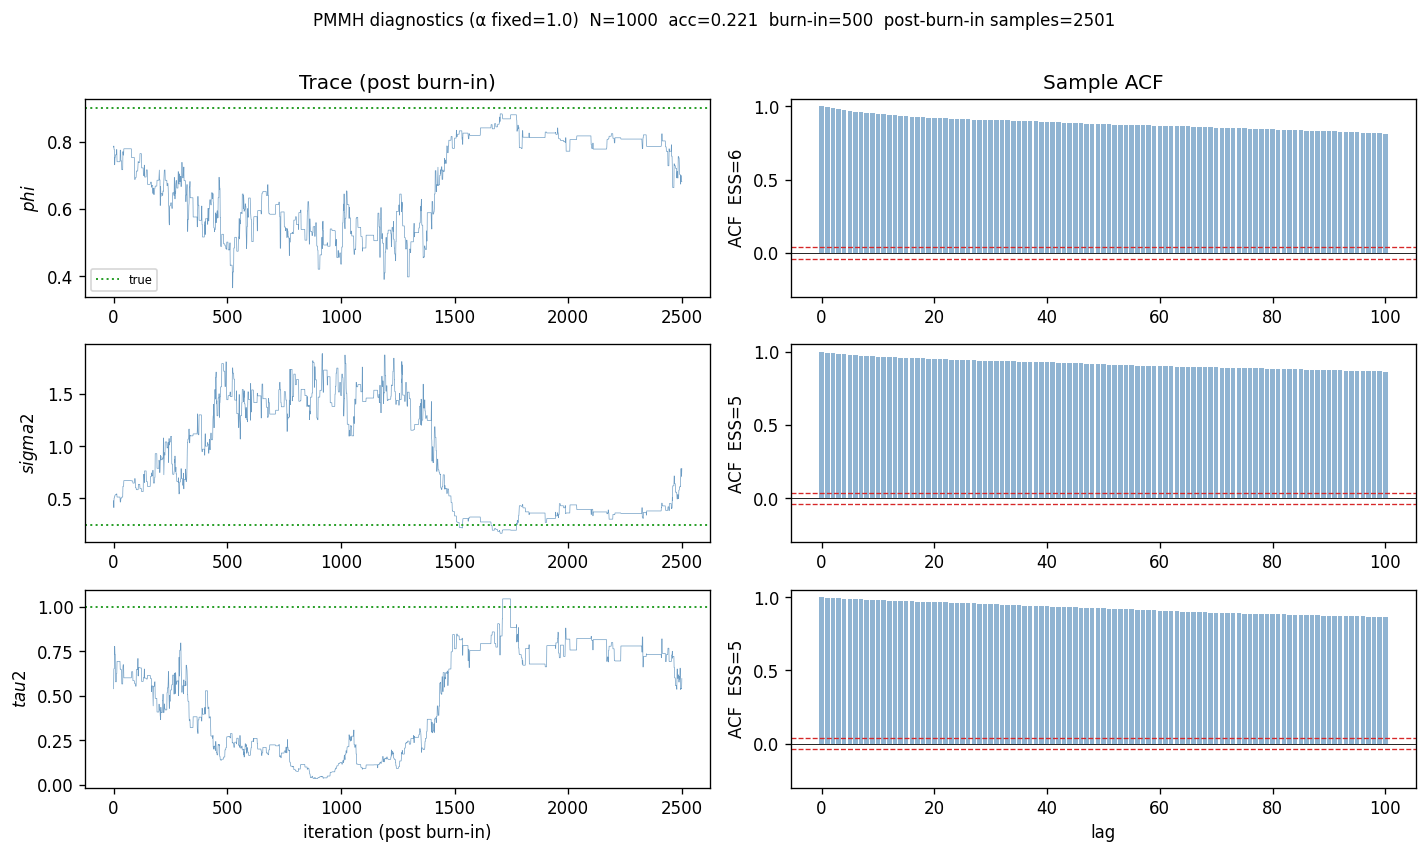

In [ ]:
names_2 = list(model_2.params_dict.keys())
fig, axes = plt.subplots(3, 2, figsize=(12, 7))

for k, name in enumerate(names_2):
    samp = constrained_2[:, k]
    tv   = TRUE_PARAMS[name]

    ax_t = axes[k, 0]
    ax_t.plot(samp, lw=0.4, color='steelblue', alpha=0.8)
    ax_t.axhline(tv, color='C2', ls=':', lw=1.2)
    ax_t.set_ylabel(f'${name}$')
    if k == 0:
        ax_t.set_title('Trace (post burn-in)')
        ax_t.plot([], [], color='C2', ls=':', lw=1.2, label='true')
        ax_t.legend(fontsize=7)

    ax_a = axes[k, 1]
    n_s  = len(samp)
    max_lag = min(100, n_s - 1)
    xc  = samp - samp.mean()
    var = xc.var()
    acf = np.correlate(xc, xc, 'full')[n_s - 1:] / (n_s * var) if var > 1e-15 else np.zeros(n_s)
    ax_a.bar(np.arange(max_lag + 1), acf[:max_lag + 1], width=0.8, color='steelblue', alpha=0.6)
    ax_a.axhline(0, color='k', lw=0.5)
    ci = 1.96 / np.sqrt(n_s)
    ax_a.axhline( ci, color='C3', ls='--', lw=0.8)
    ax_a.axhline(-ci, color='C3', ls='--', lw=0.8)
    ax_a.set_ylim(-0.3, 1.05)
    ax_a.set_ylabel(f'ACF  ESS={chain_ess(samp):.0f}')
    if k == 0:
        ax_a.set_title('Sample ACF')

axes[-1, 0].set_xlabel('iteration (post burn-in)')
axes[-1, 1].set_xlabel('lag')
plt.suptitle(
    f'PMMH diagnostics (α fixed=1.0)  N={N_PART_2}  acc={acc_2.mean():.3f}  '
    f'burn-in={BURN_IN_2}  post-burn-in samples={len(constrained_2)}',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()


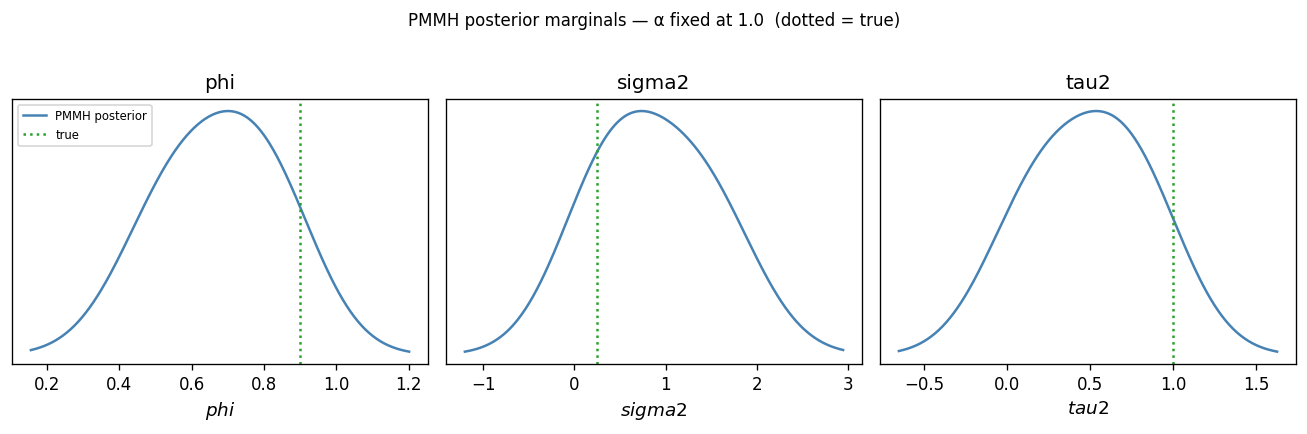

In [ ]:
names_2 = list(model_2.params_dict.keys())

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for k, (ax, name) in enumerate(zip(axes, names_2)):
    samp = constrained_2[:, k]
    tv   = TRUE_PARAMS[name]

    kde = KDE(samp)
    lo  = samp.mean() - 4 * samp.std()
    hi  = samp.mean() + 4 * samp.std()
    xg  = np.linspace(lo, hi, 400)
    ax.plot(xg, kde.evaluate(xg), lw=1.5, color='steelblue', label='PMMH posterior')
    ax.axvline(tv, color='C2', ls=':', lw=1.5, label='true')
    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(name)
    ax.set_yticks([])
    if k == 0:
        ax.legend(fontsize=7)

plt.suptitle('PMMH posterior marginals — α fixed at 1.0  (dotted = true)', y=1.02, fontsize=10)
plt.tight_layout()
plt.show()


---
## 3. Block PMMH — updating parameters in independent groups

Standard PMMH proposes a joint update to all $d$ parameters simultaneously.
With $d=3$ (after fixing $\alpha$), independent blocks can still improve mixing when
parameters have different posterior scales or posterior correlation.

**Block PMMH** (`BlockPMMH`) partitions $\theta$ into groups and cycles through them each
iteration, accepting or rejecting each block independently.  Both samplers fix $\alpha=1.0$.

Block structure for $(\phi, \sigma^2, \tau^2)$:
- **Dynamics block** $(\phi)$ — index 0: the AR(1) persistence
- **Noise block** $(\sigma^2, \tau^2)$ — indices 1 and 2: process and observation variances

We run both samplers on the **same dataset as Section 1** and compare:
- Overall acceptance rates
- Trace plots and posterior ESS
- Posterior marginals


In [ ]:
# ── setup: naive PMMH and Block PMMH, both with alpha fixed ──────────────────
# Block structure: dynamics (phi=0) and noise variances (sigma2=1, tau2=2).
BLOCKS      = [[0], [1, 2]]   # dynamics block, noise variance block
N_ITER_CMP  = 2000
N_PART_CMP  = 500
BURN_IN_CMP = 500

model_n = FixedAlphaSSM(phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                         tau2=TRUE_PARAMS['tau2'], seed=1)
model_b = FixedAlphaSSM(phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                         tau2=TRUE_PARAMS['tau2'], seed=2)

theta0_cmp = model_n.unconstrain_params(
    [TRUE_PARAMS['phi'], TRUE_PARAMS['sigma2'], TRUE_PARAMS['tau2']]
)
step_cmp = np.array([0.10, 0.15, 0.15])   # per-dim steps: (atanh φ, log σ², log τ²)

pf_n   = ParticleFilter(model_n, N_PART_CMP, obs, SystematicResampling(seed=1))
pmmh_n = PMMH(model_n, pf_n, n_iter=N_ITER_CMP,
              step_sizes=step_cmp, theta0=theta0_cmp,
              log_prior=log_prior_fixed_alpha, seed=10)

pf_b   = ParticleFilter(model_b, N_PART_CMP, obs, SystematicResampling(seed=2))
pmmh_b = BlockPMMH(model_b, pf_b, n_iter=N_ITER_CMP,
                   step_sizes=step_cmp, theta0=theta0_cmp,
                   log_prior=log_prior_fixed_alpha,
                   blocks=BLOCKS, seed=20)

print(repr(pmmh_n))
print(repr(pmmh_b))


PMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0), n_iter=2000, N_particles=500)
BlockPMMH(model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0), n_iter=2000, N_particles=500, n_blocks=2)


In [ ]:
# ── run both chains ────────────────────────────────────────────────────────────
print("Running naive PMMH (alpha fixed=1.0) ...")
chain_n, ll_n, acc_n = pmmh_n.run()
print(f"  acceptance rate: {acc_n.mean():.3f}")

print("Running Block PMMH (alpha fixed=1.0) ...")
chain_b, ll_b, acc_b = pmmh_b.run()
print(f"  acceptance rate: {acc_b.mean():.3f}")

constrained_n = model_n.constrain_chain(chain_n[BURN_IN_CMP:])
constrained_b = model_b.constrain_chain(chain_b[BURN_IN_CMP:])

names_cmp = list(model_n.params_dict.keys())
print(f"\n{'':8}  {'True':>8}  {'Naive mean':>12}  {'Block mean':>12}")
print("─" * 46)
for k, name in enumerate(names_cmp):
    print(f"{name:<8}  {TRUE_PARAMS[name]:>8.4f}  "
          f"{constrained_n[:, k].mean():>12.4f}  "
          f"{constrained_b[:, k].mean():>12.4f}")


Running naive PMMH (alpha fixed=1.0) ...
ParticleFilter.run_filter  1.106s
ParticleFilter.run_filter  1.060s
ParticleFilter.run_filter  1.105s
ParticleFilter.run_filter  1.060s
ParticleFilter.run_filter  1.046s
ParticleFilter.run_filter  1.047s
ParticleFilter.run_filter  1.206s
ParticleFilter.run_filter  1.089s
ParticleFilter.run_filter  1.082s
ParticleFilter.run_filter  1.078s
ParticleFilter.run_filter  1.076s
ParticleFilter.run_filter  1.140s
ParticleFilter.run_filter  1.057s
ParticleFilter.run_filter  1.216s
ParticleFilter.run_filter  1.081s
ParticleFilter.run_filter  1.055s
ParticleFilter.run_filter  1.041s
ParticleFilter.run_filter  1.028s
ParticleFilter.run_filter  1.094s
ParticleFilter.run_filter  1.060s
ParticleFilter.run_filter  1.018s
ParticleFilter.run_filter  1.093s
ParticleFilter.run_filter  1.052s
ParticleFilter.run_filter  1.066s
ParticleFilter.run_filter  1.073s
ParticleFilter.run_filter  1.077s
ParticleFilter.run_filter  1.070s
ParticleFilter.run_filter  1.097s
Particl

KeyboardInterrupt: 

In [ ]:
# ── trace plots and posterior comparison ──────────────────────────────────────
names_cmp = list(model_n.params_dict.keys())
fig, axes = plt.subplots(3, 3, figsize=(13, 8))

for k, name in enumerate(names_cmp):
    tv = TRUE_PARAMS[name]

    for col, (label, ch, color) in enumerate([
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]):
        ax = axes[k, col]
        ax.plot(ch[:, k], lw=0.5, color=color, alpha=0.7)
        ax.axhline(tv, color='C2', ls=':', lw=1.2, label='true' if k == 0 else None)
        ax.set_ylabel(f'${name}$' if col == 0 else '')
        if k == 0:
            ax.set_title(label)
            ax.legend(fontsize=7)

    ax_m = axes[k, 2]
    lo = min(constrained_n[:, k].min(), constrained_b[:, k].min())
    hi = max(constrained_n[:, k].max(), constrained_b[:, k].max())
    bins = np.linspace(lo, hi, 40)
    for label, ch, color in [
        ('Naive PMMH', constrained_n, 'steelblue'),
        ('Block PMMH', constrained_b, 'tomato'),
    ]:
        ax_m.hist(ch[:, k], bins=bins, density=True, alpha=0.4, color=color, label=label)
    ax_m.axvline(tv, color='C2', ls=':', lw=1.5)
    ax_m.set_xlabel(f'${name}$')
    if k == 0:
        ax_m.set_title('Posterior marginals')
        ax_m.legend(fontsize=7)

for col in range(2):
    axes[-1, col].set_xlabel('iteration (post burn-in)')
plt.suptitle(
    f'Naive PMMH (acc={acc_n.mean():.2f}) vs Block PMMH (acc={acc_b.mean():.2f})'
    r' — $\alpha$ fixed',
    y=1.01, fontsize=10,
)
plt.tight_layout()
plt.show()


---
## 4. Effect of N_particles on PMMH

The variance of the PF log-likelihood estimator scales as $O(1/N)$, which directly inflates the
posterior variance of the PMMH chain. With $\alpha$ fixed at the true value, the posterior is
identifiable and we can cleanly study the effect of $N$:

- How posterior width and chain mixing depend on $N$
- How acceptance rate and ESS depend on $N$
- How PMMH posterior means compare to the true parameter values


In [ ]:
N_VALS   = [50, 200, 500, 1000, 2000]
N_ITER_N = 1500
BURN_N   = 300
step_n   = np.array([0.06, 0.12, 0.12])   # (atanh φ, log σ², log τ²)

sweep_results = {}

for N_p in N_VALS:
    m_sw    = FixedAlphaSSM(phi=TRUE_PARAMS['phi'], sigma2=TRUE_PARAMS['sigma2'],
                             tau2=TRUE_PARAMS['tau2'], seed=11)
    pf_sw   = ParticleFilter(m_sw, N_p, obs, SystematicResampling(seed=N_p))
    pmmh_sw = PMMH(m_sw, pf_sw, n_iter=N_ITER_N,
                   step_sizes=step_n,
                   theta0=m_sw.unconstrain_params(
                       [TRUE_PARAMS['phi'], TRUE_PARAMS['sigma2'], TRUE_PARAMS['tau2']]
                   ),
                   log_prior=log_prior_fixed_alpha, seed=N_p)
    print(f"  N={N_p:5d} ...", end='', flush=True)
    ch_sw, ll_sw, acc_sw = pmmh_sw.run()
    print(f"  acc={acc_sw.mean():.3f}")
    con_sw = m_sw.constrain_chain(ch_sw[BURN_N:])
    n_params = con_sw.shape[1]
    sweep_results[N_p] = {
        'chain_con': con_sw,
        'loglik':    ll_sw[BURN_N:],
        'acc_rate':  float(acc_sw.mean()),
        'post_mean': con_sw.mean(axis=0),
        'post_std':  con_sw.std(axis=0),
        'ess':       np.array([chain_ess(con_sw[:, k]) for k in range(n_params)]),
    }
names_4 = list(m_sw.params_dict.keys())   # ['phi', 'sigma2', 'tau2']
print("Done.")


In [ ]:
trues_4 = [TRUE_PARAMS[n] for n in names_4]

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)

for k, name in enumerate(names_4):
    tv    = trues_4[k]
    means = np.array([sweep_results[N]['post_mean'][k] for N in N_VALS])
    stds  = np.array([sweep_results[N]['post_std'][k]  for N in N_VALS])

    ax_m = axes[0, k]
    ax_m.errorbar(N_VALS, means, yerr=stds, fmt='o-', color='steelblue',
                  capsize=4, ms=4, label='PMMH mean±std' if k == 0 else None)
    ax_m.axhline(tv, color='C2', ls=':', lw=1.3, label='true' if k == 0 else None)
    ax_m.set_title(f'${name}$')
    ax_m.set_xscale('log')
    if k == 0:
        ax_m.set_ylabel('parameter value')
        ax_m.legend(fontsize=7)

    ll_vars  = np.array([sweep_results[N]['loglik'].var() + 1e-10 for N in N_VALS])
    scale_1N = float(ll_vars[0]) * N_VALS[0]
    ax_v = axes[1, k]
    ax_v.plot(N_VALS, ll_vars, 'o-', color='tomato', ms=4)
    ax_v.plot(N_VALS, [scale_1N / N for N in N_VALS], 'k--', lw=0.8,
              label=r'$\propto 1/N$' if k == 0 else None)
    ax_v.set_xscale('log')
    ax_v.set_yscale('log')
    ax_v.set_xlabel('$N$ particles')
    if k == 0:
        ax_v.set_ylabel(r'Var$[\hat{\ell}]$')
        ax_v.legend(fontsize=7)

plt.suptitle(
    r'Effect of $N$ — PMMH posterior mean/std (top) and log-lik variance (bottom)'
    r' — $\alpha$ fixed',
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

accs = [sweep_results[N]['acc_rate'] for N in N_VALS]
fig2, ax2 = plt.subplots(figsize=(5, 3))
ax2.plot(N_VALS, accs, 'o-', color='seagreen', ms=5)
ax2.set_xscale('log')
ax2.set_xlabel('$N$ particles')
ax2.set_ylabel('acceptance rate')
ax2.set_title(r'PMMH acceptance rate vs $N$ — $\alpha$ fixed')
ax2.axhline(0.234, color='C3', ls='--', lw=0.8, label='0.234 (optimal RW)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
colors_N  = plt.cm.viridis(np.linspace(0.1, 0.9, len(N_VALS)))

for k, name in enumerate(names_4):
    ax = axes[k]
    tv = trues_4[k]

    all_samp = np.concatenate([sweep_results[N]['chain_con'][:, k] for N in N_VALS])
    lo = np.percentile(all_samp, 1)
    hi = np.percentile(all_samp, 99)
    margin = 0.08 * (hi - lo)
    xg = np.linspace(lo - margin, hi + margin, 400)

    for i, N_p in enumerate(N_VALS):
        samp = sweep_results[N_p]['chain_con'][:, k]
        kde  = KDE(samp)
        ax.plot(xg, kde.evaluate(xg), lw=1.2, color=colors_N[i],
                label=f'N={N_p}' if k == 0 else None)

    ax.axvline(tv, color='C2', ls=':', lw=1.5, label='true' if k == 0 else None)
    ax.set_xlabel(f'${name}$', fontsize=11)
    ax.set_title(f'{name} posterior')
    ax.set_yticks([])
    if k == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    r'Posterior KDE by $N$ — darker = larger $N$  (dotted = true) — $\alpha$ fixed',
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()


In [ ]:
# ── 2-D log-likelihood surface over (phi, sigma2) ─────────────────────────────
# With alpha fixed, phi and sigma2 are identifiable. We visualize the posterior
# geometry of the identified parameters and overlay PMMH N=1000 samples.
alpha_fix2 = TRUE_PARAMS['alpha']   # 1.0 (fixed)
tau2_fix2  = TRUE_PARAMS['tau2']
n_grid     = 70

phi_grid    = np.linspace(-0.97, 0.97, n_grid)
sigma2_grid = np.linspace(0.01, 1.5, n_grid)
PP, SS = np.meshgrid(phi_grid, sigma2_grid)
LL = np.full_like(PP, np.nan)

for i in range(n_grid):
    for j in range(n_grid):
        try:
            m_grid = SimpleLinearGaussianSSM(PP[i, j], alpha_fix2, SS[i, j], tau2_fix2)
            LL[i, j] = m_grid.log_likelihood(obs)
        except (ValueError, FloatingPointError):
            pass

vmin = np.nanpercentile(LL, 5)
vmax = np.nanmax(LL)

fig, ax = plt.subplots(figsize=(7, 5.5))
cf = ax.contourf(PP, SS, LL, levels=40, cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(cf, ax=ax, label='log p(y | θ)')

samp_plot = sweep_results[1000]['chain_con']
ax.scatter(samp_plot[:, 0], samp_plot[:, 1], c='white', s=3, alpha=0.3,
           label='PMMH  N=1000')
ax.axvline(TRUE_PARAMS['phi'],    color='red',    ls=':', lw=1.5, label=r'true $\phi$')
ax.axhline(TRUE_PARAMS['sigma2'], color='orange', ls=':', lw=1.5, label=r'true $\sigma^2$')
ax.set_xlabel(r'$\phi$', fontsize=12)
ax.set_ylabel(r'$\sigma^2$', fontsize=12)
ax.set_title(
    r'Log-likelihood over $(\phi, \sigma^2)$ with $\alpha=1$ (fixed), $\tau^2$ at true value'
    '\n' r'With $\alpha$ fixed, both $\phi$ and $\sigma^2$ are identifiable'
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


---
## 5. Effect of observation noise on parameter estimation

Higher observation noise $\tau$ reduces the signal available for identifying the latent process
parameters $(\phi, \sigma)$. We sweep `tau_true` and examine:

- MLE estimation error (bias and variance across MC trials) for each parameter
- PMMH posterior width as a function of `tau_true`
- Whether the signal-to-noise ratio $\sigma / \tau$ is a better predictor of estimation quality
  than $\tau$ alone
- Limits of recoverability: at what $\tau$ does parameter estimation become unreliable?

In [ ]:
TAU_VALS    = [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]   # tau (std dev) values
N_MC_TAU    = 15
BASE_PARAMS = dict(phi=0.9, alpha=1.0, sigma2=0.25)    # sigma2 = 0.5^2

tau_mle_results = {}
rng_tau = np.random.default_rng(321)

for tau_v in TAU_VALS:
    true_p    = {**BASE_PARAMS, 'tau2': tau_v**2}   # tau2 = tau^2
    estimates = {n: np.full(N_MC_TAU, np.nan) for n in ['phi', 'alpha', 'sigma2', 'tau2']}
    print(f"tau={tau_v:.2f} ", end='', flush=True)
    for trial in range(N_MC_TAU):
        seed_t = int(rng_tau.integers(0, 100000))
        m_t    = SimpleLinearGaussianSSM(**true_p, seed=seed_t)
        _, obs_trial, _ = m_t.generate_data(300)
        obs_trial = obs_trial.ravel()
        try:
            res_t = MLEEstimator(m_t, obs_trial, n_restarts=2, seed=seed_t).fit()
            for k, pname in enumerate(['phi', 'alpha', 'sigma2', 'tau2']):
                estimates[pname][trial] = list(res_t.constrained_params)[k]
        except Exception:
            pass
    tau_mle_results[tau_v] = estimates
    print(f"  phi={np.nanmean(estimates['phi']):.3f}  tau2={np.nanmean(estimates['tau2']):.3f}")

print("Done.")


In [ ]:
TAU_PMMH_VALS = [0.5, 1.0, 2.0]
N_ITER_TAU    = 1500
N_PART_TAU    = 500
BURN_TAU      = 300
step_tau      = np.array([0.06, 0.10, 0.12, 0.12])   # (atanh φ, α, log σ², log τ²)

tau_pmmh_results = {}

for tau_v in TAU_PMMH_VALS:
    true_p = {**BASE_PARAMS, 'tau2': tau_v**2}
    # generate a fresh dataset for this tau value
    m_gen  = SimpleLinearGaussianSSM(**true_p, seed=77)
    _, obs_tv, _ = m_gen.generate_data(300)
    obs_tv = obs_tv.ravel()
    # MLE warm start
    res_tv = MLEEstimator(SimpleLinearGaussianSSM(**true_p, seed=78), obs_tv,
                          n_restarts=2, seed=78).fit()
    theta0_tv = res_tv.unconstrained_params
    # PMMH
    m_tv   = SimpleLinearGaussianSSM(**true_p, seed=79)
    pf_tv  = ParticleFilter(m_tv, N_PART_TAU, obs_tv,
                             SystematicResampling(seed=int(tau_v * 100)))
    pmmh_tv = PMMH(m_tv, pf_tv, n_iter=N_ITER_TAU,
                   step_sizes=step_tau, theta0=theta0_tv,
                   log_prior=log_prior, seed=77)
    print(f"tau={tau_v:.1f} ...", end='', flush=True)
    ch_tv, _, acc_tv = pmmh_tv.run()
    print(f"  acc={acc_tv.mean():.3f}")
    tau_pmmh_results[tau_v] = {
        'chain_con': m_tv.constrain_chain(ch_tv[BURN_TAU:]),
        'acc':       float(acc_tv.mean()),
    }

print("Done.")


In [ ]:
names_tau  = ['phi', 'alpha', 'sigma2', 'tau2']
true_fixed = {'phi': 0.9, 'alpha': 1.0, 'sigma2': 0.25}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for k, name in enumerate(names_tau):
    mle_means = [np.nanmean(tau_mle_results[tv][name]) for tv in TAU_VALS]
    mle_stds  = [np.nanstd(tau_mle_results[tv][name])  for tv in TAU_VALS]

    ax_m = axes[0, k]
    ax_m.errorbar(TAU_VALS, mle_means, yerr=mle_stds,
                  fmt='o-', color='steelblue', capsize=4, ms=4)
    if name != 'tau2':
        ax_m.axhline(true_fixed[name], color='C2', ls=':', lw=1.3,
                     label='true' if k == 0 else None)
    else:
        ax_m.plot(TAU_VALS, [tv**2 for tv in TAU_VALS], color='C2', ls=':', lw=1.3,
                  label='true' if k == 0 else None)
    ax_m.set_title(f'MLE  ${name}$')
    ax_m.set_xlabel(r'true $\tau$')
    if k == 0:
        ax_m.set_ylabel('estimate ± std (N_MC trials)')
        ax_m.legend(fontsize=7)

    pmmh_stds = [tau_pmmh_results[tv]['chain_con'][:, k].std() for tv in TAU_PMMH_VALS]
    ax_s = axes[1, k]
    ax_s.plot(TAU_PMMH_VALS, pmmh_stds, 'o-', color='tomato', ms=5)
    ax_s.set_xlabel(r'true $\tau$')
    ax_s.set_title(f'PMMH std  ${name}$')
    if k == 0:
        ax_s.set_ylabel('PMMH posterior std')

plt.suptitle(r'Parameter recoverability vs observation noise $\tau$', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


---
## 6. Model misspecification

We fit a `SimpleLinearGaussianSSM` (Gaussian noise, AR(1) latent) to data generated from:
- `LinearTSSM` — same AR(1) structure but with t-distributed process noise (heavy tails)
- `LinearARMASSM` — ARMA(1,3) latent process, richer autocorrelation structure

For each case we examine:
- MLE estimates under the misspecified model — which parameters absorb the specification error?
- PMMH posteriors under misspecification — does the posterior collapse or widen?
- Goodness-of-fit diagnostics: residual autocorrelation, filtered state RMSE, log-likelihood gap
  between the misspecified MLE and the correct model's true log-likelihood

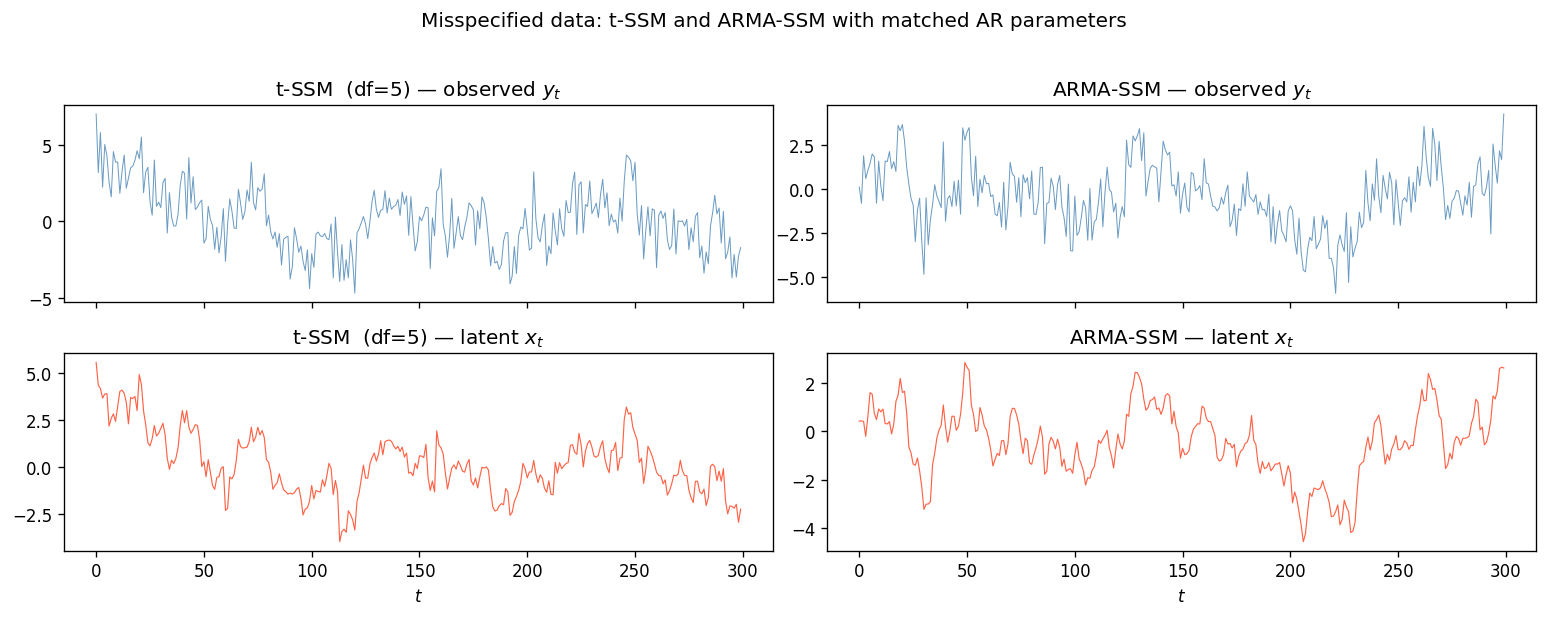

In [ ]:
MISSPEC_T    = 300
MISSPEC_SEED = 55
M_PHI, M_ALPHA, M_SIGMA, M_TAU = 0.9, 1.0, 0.5, 1.0

# ── t-distributed process noise ───────────────────────────────────────────────
t_model  = LinearTSSM(phi=M_PHI, alpha=M_ALPHA, sigma=M_SIGMA, tau=M_TAU,
                      df=5, seed=MISSPEC_SEED)
states_t_raw, obs_t_raw, _ = t_model.generate_data(MISSPEC_T)
states_t = states_t_raw.ravel()
obs_t    = obs_t_raw.ravel()

# ── ARMA(1,3) latent process ──────────────────────────────────────────────────
arma_model = LinearARMASSM(phi=M_PHI, alpha=M_ALPHA, c=0,
                            theta_1=0.3, theta_2=0.1, theta_3=0.05,
                            sigma=M_SIGMA, tau=M_TAU, seed=MISSPEC_SEED)
states_a_raw, obs_a_raw, _ = arma_model.generate_data(MISSPEC_T)
states_a = states_a_raw[:, 0]   # x_t component of the 4-D augmented state
obs_a    = obs_a_raw.ravel()

fig, axes = plt.subplots(2, 2, figsize=(13, 5), sharex=True)
for col, (label, ys, xs) in enumerate([
    ('t-SSM  (df=5)',  obs_t, states_t),
    ('ARMA-SSM',       obs_a, states_a),
]):
    axes[0, col].plot(ys, lw=0.6, color='steelblue', alpha=0.8)
    axes[0, col].set_title(f'{label} — observed $y_t$')
    axes[1, col].plot(xs, lw=0.7, color='tomato')
    axes[1, col].set_title(f'{label} — latent $x_t$')
    axes[1, col].set_xlabel('$t$')

plt.suptitle('Misspecified data: t-SSM and ARMA-SSM with matched AR parameters', y=1.02)
plt.tight_layout()
plt.show()

MLEEstimator.fit  0.085s
MLE fit to t-SSM data:
MLEResult  loglik=-537.3423  converged  n_evals=65
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.952344      0.024899
  alpha                 0.885618             —
  sigma                 0.652450             —
  tau                   1.148749      0.067868


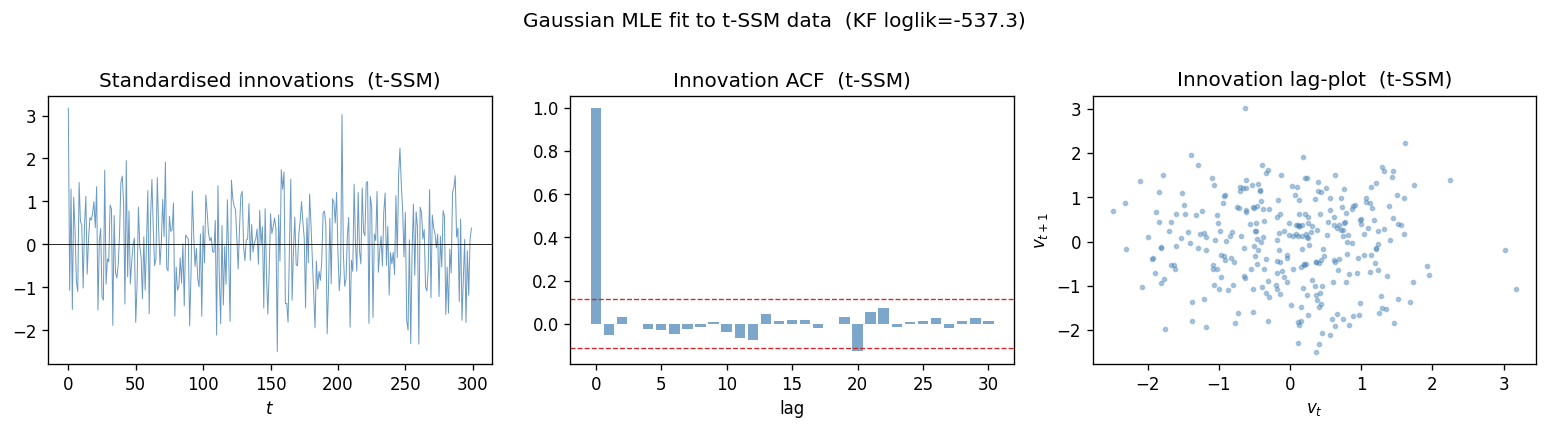

In [ ]:
# ── fit SimpleLinearGaussianSSM (MLE) to t-SSM data ───────────────────────────
gauss_t   = SimpleLinearGaussianSSM(M_PHI, M_ALPHA, M_SIGMA, M_TAU, seed=99)
mle_t     = MLEEstimator(gauss_t, obs_t, n_restarts=3, seed=0)
result_t  = mle_t.fit()
mle_t.compute_std_errors()
print("MLE fit to t-SSM data:")
print(result_t.summary())

# ── Kalman filter under misspecified model → innovation diagnostics ────────────
phi_t_m, alpha_t_m, sigma_t_m, tau_t_m = result_t.constrained_params
lg_t = LinearGaussianSSM(
    a=np.array([[phi_t_m]]), c=np.array([[alpha_t_m]]),
    q=np.array([[sigma_t_m**2]]), r=np.array([[tau_t_m**2]]),
)
kf_t = KalmanFilter(lg_t, obs_t)
filt_t, _, kf_loglik_t = kf_t.run_filter()

innovations_t = kf_t.innovations.ravel()
inn_std_t     = np.sqrt(kf_t.innovation_covs[:, 0, 0])
xc_t  = innovations_t - innovations_t.mean()
var_t = xc_t.var()
acf_inn_t = (np.correlate(xc_t, xc_t, 'full')[MISSPEC_T - 1:] / (MISSPEC_T * var_t)
             if var_t > 0 else np.zeros(MISSPEC_T))

max_lag = 30
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(innovations_t / inn_std_t, lw=0.6, color='steelblue', alpha=0.8)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('Standardised innovations  (t-SSM)')
axes[0].set_xlabel('$t$')

axes[1].bar(range(max_lag + 1), acf_inn_t[:max_lag + 1], color='steelblue', alpha=0.7)
axes[1].axhline( 1.96 / np.sqrt(MISSPEC_T), color='C3', ls='--', lw=0.8)
axes[1].axhline(-1.96 / np.sqrt(MISSPEC_T), color='C3', ls='--', lw=0.8)
axes[1].set_title('Innovation ACF  (t-SSM)')
axes[1].set_xlabel('lag')

axes[2].scatter(innovations_t[:-1] / inn_std_t[:-1],
                innovations_t[1:]  / inn_std_t[1:],
                s=6, alpha=0.4, color='steelblue')
axes[2].set_xlabel('$v_t$')
axes[2].set_ylabel('$v_{t+1}$')
axes[2].set_title('Innovation lag-plot  (t-SSM)')

plt.suptitle(f'Gaussian MLE fit to t-SSM data  (KF loglik={kf_loglik_t:.1f})', y=1.01)
plt.tight_layout()
plt.show()

MLEEstimator.fit  0.076s
MLE fit to ARMA-SSM data:
MLEResult  loglik=-510.9278  converged  n_evals=60
  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

  Parameter             Estimate     Std error
  --------------------------------------------
  phi                   0.929663      0.026654
  alpha                 1.073504    267.684050
  sigma                 0.537271    133.978049
  tau                   1.031319      0.061667

True ARMA KF loglik:          -511.7
Misspecified Gauss MLE loglik: -510.9
Log-lik gap:                   0.7


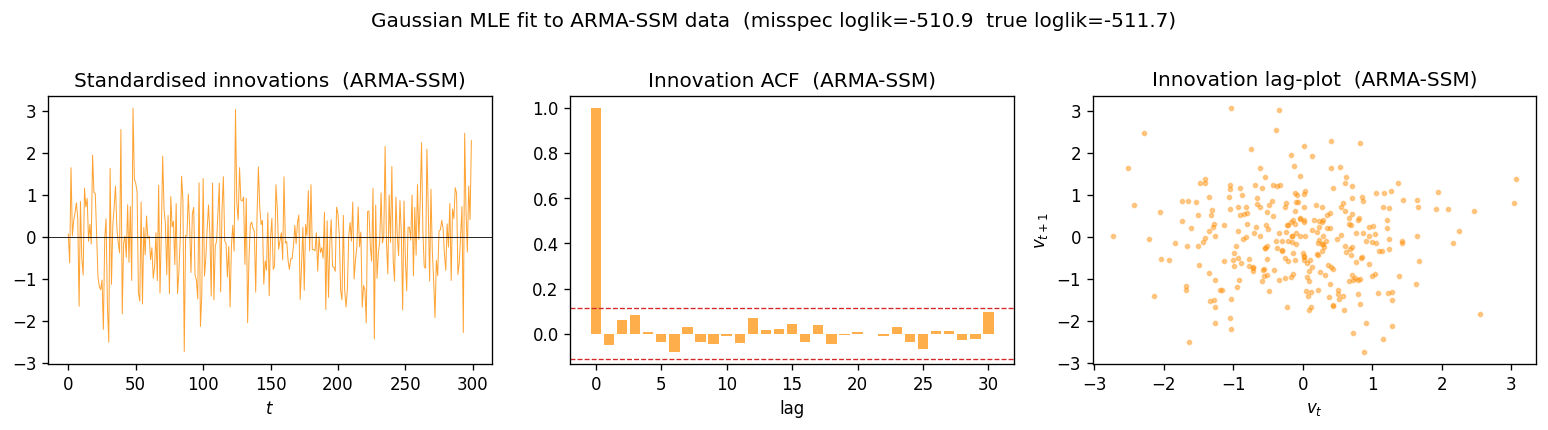

In [ ]:
# ── fit SimpleLinearGaussianSSM (MLE) to ARMA-SSM data ────────────────────────
gauss_a   = SimpleLinearGaussianSSM(M_PHI, M_ALPHA, M_SIGMA, M_TAU, seed=99)
mle_a     = MLEEstimator(gauss_a, obs_a, n_restarts=3, seed=0)
result_a  = mle_a.fit()
mle_a.compute_std_errors()
print("MLE fit to ARMA-SSM data:")
print(result_a.summary())

# ── True ARMA log-likelihood via LinearGaussianSSM companion form ─────────────
# State s_t = [x_t, nu_t, nu_{t-1}, nu_{t-2}]
# x_t = c + phi*x_{t-1} + th1*nu_{t-1} + th2*nu_{t-2} + th3*nu_{t-3} + nu_t
phi_r  = arma_model.phi
th1, th2, th3 = arma_model.theta_1, arma_model.theta_2, arma_model.theta_3
c_r    = arma_model.c
sig_r  = arma_model.sigma
tau_r  = arma_model.tau
alp_r  = arma_model.alpha

A_arma = np.array([[phi_r, th1,  th2,  th3],
                   [0,     0,    0,    0  ],
                   [0,     1,    0,    0  ],
                   [0,     0,    1,    0  ]])
B_arma = np.array([1.0, 1.0, 0.0, 0.0])       # nu_t enters x_t and the nu_t slot
Q_arma = sig_r**2 * np.outer(B_arma, B_arma)
C_arma = np.array([[alp_r, 0, 0, 0]])
R_arma = np.array([[tau_r**2]])
b_arma = np.array([c_r, 0.0, 0.0, 0.0])

lg_arma_true     = LinearGaussianSSM(a=A_arma, c=C_arma, q=Q_arma, r=R_arma, b=b_arma)
true_loglik_arma = lg_arma_true.log_likelihood(obs_a)
print(f"\nTrue ARMA KF loglik:          {true_loglik_arma:.1f}")
print(f"Misspecified Gauss MLE loglik: {result_a.loglik:.1f}")
print(f"Log-lik gap:                   {result_a.loglik - true_loglik_arma:.1f}")

# ── Kalman filter under misspecified model → innovation diagnostics ────────────
phi_a_m, alpha_a_m, sigma_a_m, tau_a_m = result_a.constrained_params
lg_a = LinearGaussianSSM(
    a=np.array([[phi_a_m]]), c=np.array([[alpha_a_m]]),
    q=np.array([[sigma_a_m**2]]), r=np.array([[tau_a_m**2]]),
)
kf_a = KalmanFilter(lg_a, obs_a)
filt_a, _, kf_loglik_a = kf_a.run_filter()

innovations_a = kf_a.innovations.ravel()
inn_std_a     = np.sqrt(kf_a.innovation_covs[:, 0, 0])
xc_a  = innovations_a - innovations_a.mean()
var_a = xc_a.var()
acf_inn_a = (np.correlate(xc_a, xc_a, 'full')[MISSPEC_T - 1:] / (MISSPEC_T * var_a)
             if var_a > 0 else np.zeros(MISSPEC_T))

max_lag = 30
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(innovations_a / inn_std_a, lw=0.6, color='darkorange', alpha=0.8)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('Standardised innovations  (ARMA-SSM)')
axes[0].set_xlabel('$t$')

axes[1].bar(range(max_lag + 1), acf_inn_a[:max_lag + 1], color='darkorange', alpha=0.7)
axes[1].axhline( 1.96 / np.sqrt(MISSPEC_T), color='C3', ls='--', lw=0.8)
axes[1].axhline(-1.96 / np.sqrt(MISSPEC_T), color='C3', ls='--', lw=0.8)
axes[1].set_title('Innovation ACF  (ARMA-SSM)')
axes[1].set_xlabel('lag')

axes[2].scatter(innovations_a[:-1] / inn_std_a[:-1],
                innovations_a[1:]  / inn_std_a[1:],
                s=6, alpha=0.4, color='darkorange')
axes[2].set_xlabel('$v_t$')
axes[2].set_ylabel('$v_{t+1}$')
axes[2].set_title('Innovation lag-plot  (ARMA-SSM)')

plt.suptitle(
    f'Gaussian MLE fit to ARMA-SSM data  '
    f'(misspec loglik={result_a.loglik:.1f}  true loglik={true_loglik_arma:.1f})',
    y=1.01,
)
plt.tight_layout()
plt.show()

                                           t-SSM        ARMA-SSM
──────────────────────────────────────────────────────────────────
Misspec Gauss MLE loglik                  -537.3          -510.9
True model loglik                         -545.8          -511.7
Log-lik gap (misspec − true)                 8.5             0.7
──────────────────────────────────────────────────────────────────
bias: phi                                +0.0523         +0.0297
bias: alpha                              -0.1144         +0.0735
bias: sigma                              +0.1525         +0.0373
bias: tau                                +0.1487         +0.0313
──────────────────────────────────────────────────────────────────
Innovation ACF lag-1                     -0.0502         -0.0518


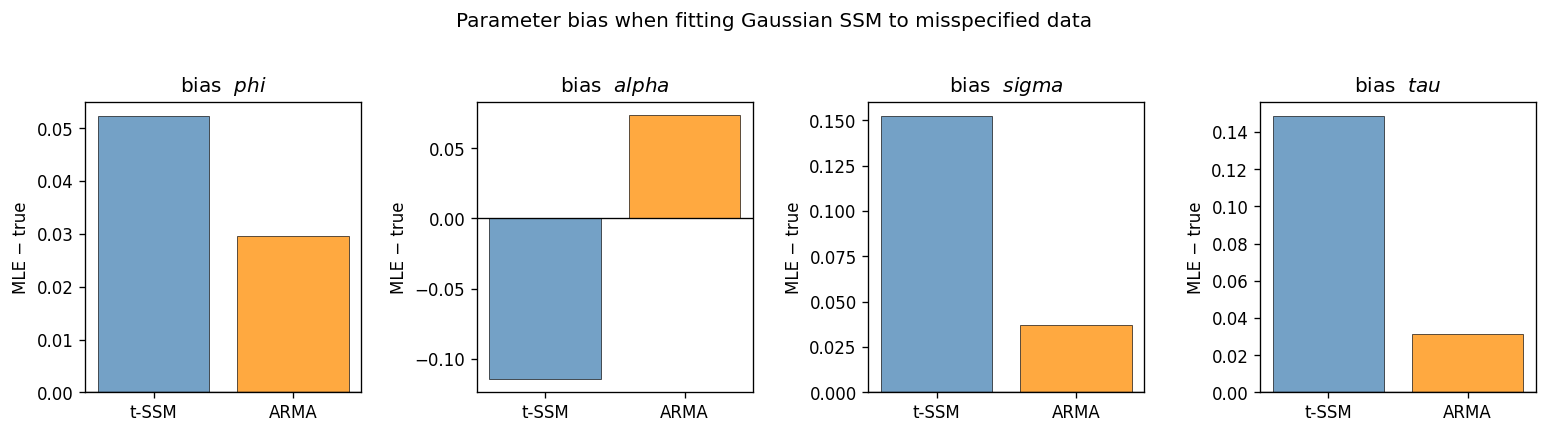

In [ ]:
# ── PF estimate of true t-SSM log-likelihood ─────────────────────────────────
# p(y | θ_t, t-model) is intractable in closed form; estimate with a PF.
t_model_pf = LinearTSSM(phi=M_PHI, alpha=M_ALPHA, sigma=M_SIGMA, tau=M_TAU, df=5, seed=0)
pf_t_ref   = ParticleFilter(t_model_pf, 2000, obs_t, SystematicResampling(seed=0))
_, _, _, _, ll_t_true_pf = pf_t_ref.run_filter()

print(f"{'':32s}  {'t-SSM':>14}  {'ARMA-SSM':>14}")
print("─" * 66)
print(f"{'Misspec Gauss MLE loglik':<32}  {result_t.loglik:>14.1f}  {result_a.loglik:>14.1f}")
print(f"{'True model loglik':<32}  {ll_t_true_pf:>14.1f}  {true_loglik_arma:>14.1f}")
print(f"{'Log-lik gap (misspec − true)':<32}  {result_t.loglik - ll_t_true_pf:>14.1f}  {result_a.loglik - true_loglik_arma:>14.1f}")
print("─" * 66)
true_p_ref = [M_PHI, M_ALPHA, M_SIGMA, M_TAU]
for k, pname in enumerate(['phi', 'alpha', 'sigma', 'tau']):
    tv = true_p_ref[k]
    mt = list(result_t.constrained_params)[k]
    ma = list(result_a.constrained_params)[k]
    print(f"{'bias: ' + pname:<32}  {mt - tv:>+14.4f}  {ma - tv:>+14.4f}")
print("─" * 66)
print(f"{'Innovation ACF lag-1':<32}  {acf_inn_t[1]:>14.4f}  {acf_inn_a[1]:>14.4f}")

# ── parameter bias bar chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for k, (ax, pname) in enumerate(zip(axes, ['phi', 'alpha', 'sigma', 'tau'])):
    tv = true_p_ref[k]
    mt = list(result_t.constrained_params)[k]
    ma = list(result_a.constrained_params)[k]
    ax.bar(['t-SSM', 'ARMA'], [mt - tv, ma - tv],
           color=['steelblue', 'darkorange'], alpha=0.75, edgecolor='k', linewidth=0.5)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'bias  ${pname}$')
    ax.set_ylabel('MLE − true')

plt.suptitle('Parameter bias when fitting Gaussian SSM to misspecified data', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Regime-switching model estimation

Markov-switching state-space models combine a discrete hidden Markov chain
$s_t \in \{0, \ldots, K-1\}$ with per-regime linear Gaussian dynamics.
The marginal likelihood over all $K^T$ possible regime sequences is intractable,
which rules out direct KF MLE.

We compare three approaches on a 2-regime model where the regimes differ only in
process noise variance (low-volatility vs high-volatility state):

| Method | Likelihood | Notes |
|--------|-----------|-------|
| Naive PMMH | PF log-lik (unbiased) | Joint proposal over all parameters |
| Block PMMH | PF log-lik (unbiased) | Transition matrix and per-regime params in separate blocks |
| Kim filter MLE | Approximate Kim log-lik | Deterministic, fast; bias from the collapse approximation |

True transition matrix: $P_{00}=0.95$, $P_{11}=0.90$ (persistent regimes).

RegimeSwitchingSSM
  Regime-switching linear Gaussian SSM (No parameters shared)
  State dim: 1,  Obs dim: 1,  Regimes: 2
  Latent state: (x_t, s_t)  where s_t in {0, ..., 1}
  Transition:  x_t | s_t ~ N(A_{s_t} x_{t-1},  Q_{s_t})
  Observation: y_t | s_t ~ N(C_{s_t} x_t,         R_{s_t})
  Regime:      P(s_t = j | s_{t-1} = i) = P_ij
  Regime transition matrix:
[[0.95 0.05]
 [0.1  0.9 ]]
  Stationary regime probs: [0.66666667 0.33333333]
Fraction in regime 1: 0.310  (stationary: 0.333)


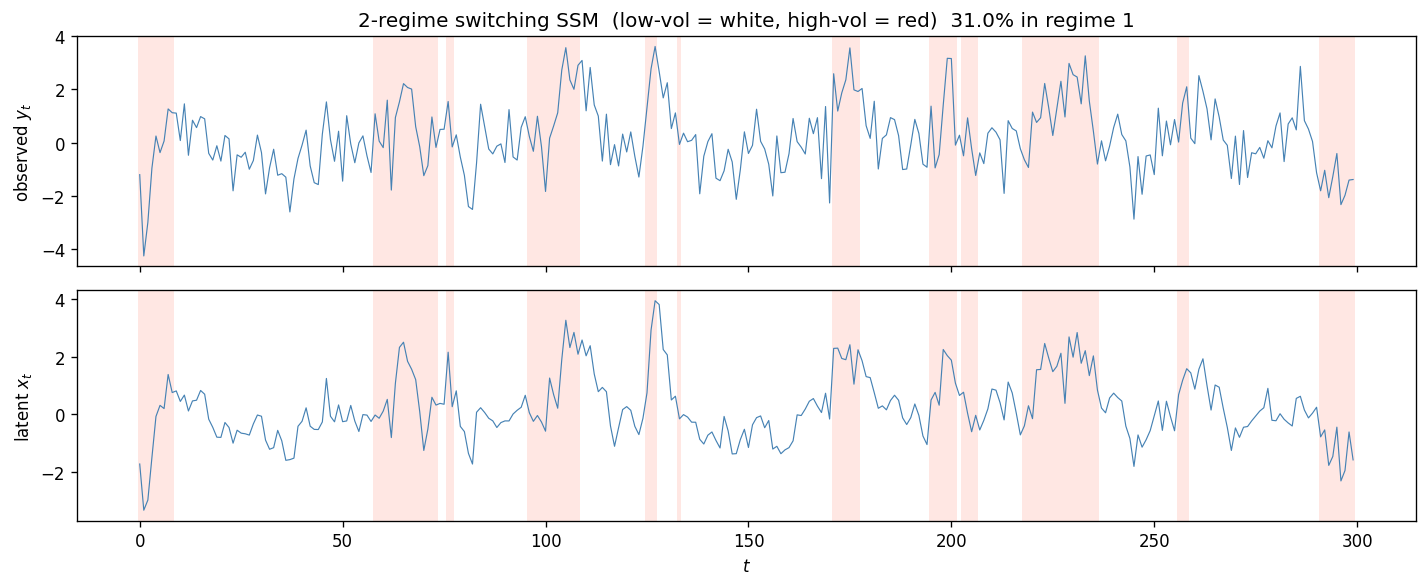

In [ ]:
# ── 2-regime switching model: setup and data generation ───────────────────────
from models.regime_switching import RegimeSwitchingSSM
from estimation.kim_filter import KimFilter

# Regime 0: low-volatility  |  Regime 1: high-volatility
phi_r  = 0.8
A_list = [np.array([[phi_r]]), np.array([[phi_r]])]
C_list = [np.array([[1.0]]),   np.array([[1.0]])]
Q_list = [np.array([[0.25]]),  np.array([[1.00]])]   # σ² per regime
R_list = [np.array([[0.50]]),  np.array([[0.50]])]   # shared obs noise

P_true_rs = np.array([[0.95, 0.05],
                      [0.10, 0.90]])

rs_model = RegimeSwitchingSSM(A_list, C_list, Q_list, R_list, P_true_rs, seed=42)
print(rs_model.describe())

# ── generate data via explicit loop ───────────────────────────────────────────
# (base generate_data is incompatible: sample_initial_distribution returns (x, regime))
T_RS       = 300
states_rs  = np.zeros((T_RS, rs_model.state_dim))
regimes_rs = np.zeros(T_RS, dtype=int)
obs_rs     = np.zeros(T_RS)

x0, r0 = rs_model.sample_initial_distribution()
states_rs[0]  = x0
regimes_rs[0] = r0
obs_rs[0]     = rs_model.observation(x0, r0).ravel()[0]

for t in range(1, T_RS):
    r_prev        = regimes_rs[t - 1]
    r_t           = rs_model.rng.choice(rs_model.n_regimes, p=P_true_rs[r_prev])
    x_t           = rs_model.transition(states_rs[t - 1], r_t)
    obs_rs[t]     = rs_model.observation(x_t, r_t).ravel()[0]
    states_rs[t]  = x_t
    regimes_rs[t] = r_t

pct_r1 = (regimes_rs == 1).mean()
print(f"Fraction in regime 1: {pct_r1:.3f}  "
      f"(stationary: {rs_model.regime_probabilities_stationary[1]:.3f})")

# ── plot with regime-coloured background ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, vals, lbl in [(ax1, obs_rs, 'observed $y_t$'),
                       (ax2, states_rs[:, 0], 'latent $x_t$')]:
    ax.plot(vals, lw=0.7, color='steelblue', zorder=2)
    ax.set_ylabel(lbl)
    for t in range(T_RS):
        if regimes_rs[t] == 1:
            ax.axvspan(t - 0.5, t + 0.5, color='tomato', alpha=0.15, lw=0)

ax2.set_xlabel('$t$')
ax1.set_title(f'2-regime switching SSM  (low-vol = white, high-vol = red)  '
              f'{pct_r1*100:.1f}% in regime 1')
plt.tight_layout()
plt.show()

In [ ]:
# ── PMMH for the regime-switching model — future work ─────────────────────────
# Running PMMH on RegimeSwitchingSSM requires two additions:
#
#   1. constrain_params / unconstrain_params on RegimeSwitchingSSM:
#      e.g. row-softmax for each row of the transition matrix P,
#           log transforms for per-regime diagonal Q and R variances.
#
#   2. An augmented particle state that jointly tracks (x_t, s_t).
#      The transition step must first sample a new regime from P[s_{t-1}, :],
#      then sample x_t | s_t, x_{t-1} from the per-regime Gaussian.
#      The observation density is p(y_t | x_t, s_t).
#
# Once those are in place, naive and block PMMH follow the same pattern as
# Sections 2-3.  The Kim filter approach in the next cell is available now
# as a fast, deterministic alternative for state filtering and approximate MLE.
print("PMMH for RegimeSwitchingSSM: requires constrain/unconstrain_params + "
      "regime-augmented PF state.  See comments above.  Proceeding to Kim filter.")

PMMH for RegimeSwitchingSSM: requires constrain/unconstrain_params + regime-augmented PF state.  See comments above.  Proceeding to Kim filter.


KimFilter.run_filter  0.062s
Kim approximate log-likelihood:   -445.22
Filtered regime probs (last step): [0.7566 0.2434]


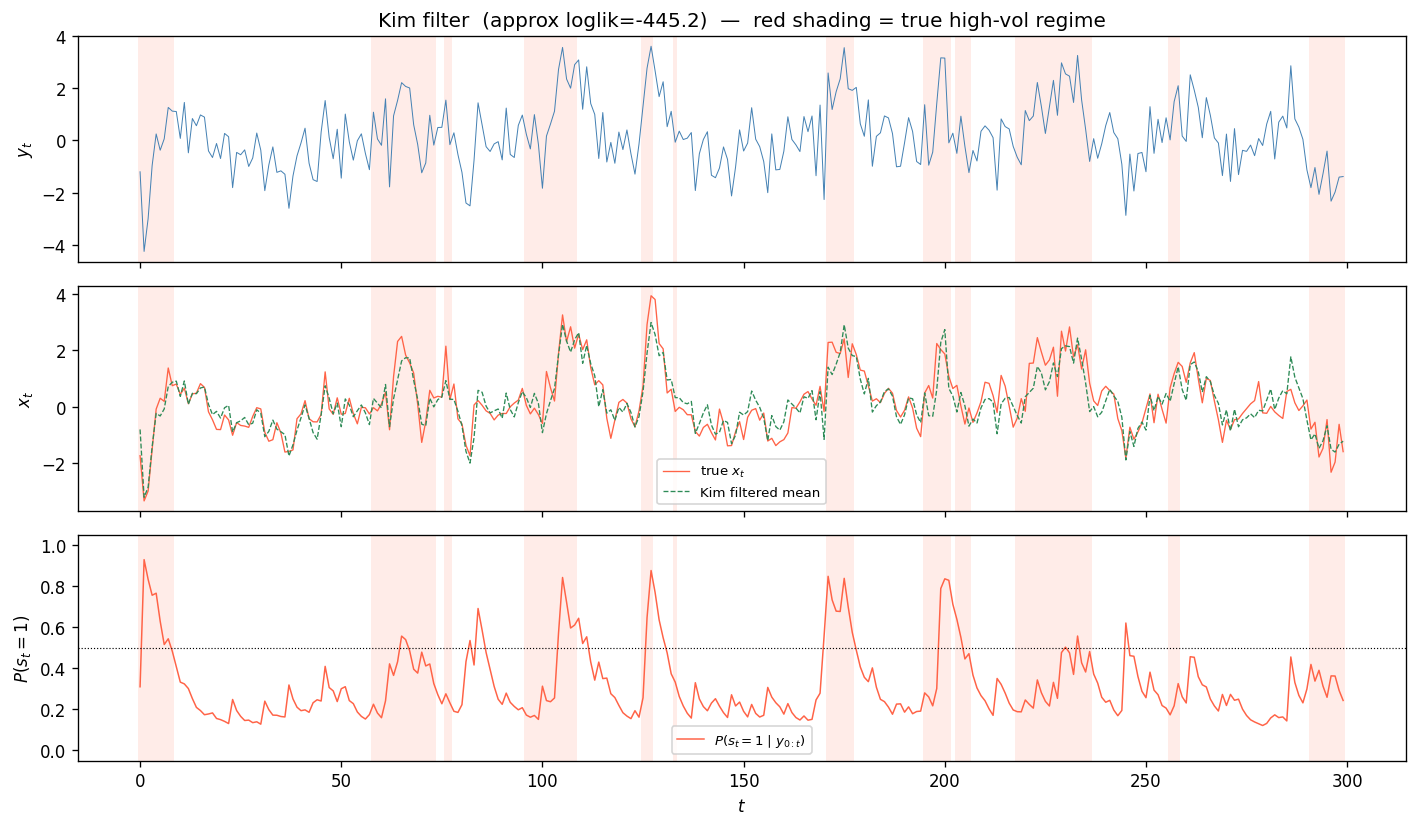

In [ ]:
# ── Kim filter on the 2-regime switching model ────────────────────────────────
kf_kim = KimFilter(rs_model, obs_rs)
filtered_means_km, filtered_probs_km, loglik_km = kf_kim.run_filter()

print(f"Kim approximate log-likelihood:   {loglik_km:.2f}")
print(f"Filtered regime probs (last step): {np.round(filtered_probs_km[-1], 4)}")

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(obs_rs, lw=0.6, color='steelblue', zorder=2)
axes[0].set_ylabel('$y_t$')

axes[1].plot(states_rs[:, 0],        lw=0.8, color='tomato',
             label='true $x_t$', zorder=2)
axes[1].plot(filtered_means_km[:, 0], lw=0.8, color='seagreen', ls='--',
             label='Kim filtered mean', zorder=3)
axes[1].set_ylabel('$x_t$')
axes[1].legend(fontsize=8)

axes[2].plot(filtered_probs_km[:, 1], lw=0.9, color='tomato',
             label=r'$P(s_t = 1 \mid y_{0:t})$')
axes[2].axhline(0.5, color='k', ls=':', lw=0.7)
axes[2].set_ylabel(r'$P(s_t=1)$')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(fontsize=8)
axes[2].set_xlabel('$t$')

# shade true regime-1 periods on all panels
for ax in axes:
    for t in range(T_RS):
        if regimes_rs[t] == 1:
            ax.axvspan(t - 0.5, t + 0.5, color='tomato', alpha=0.12, lw=0)

axes[0].set_title(
    f'Kim filter  (approx loglik={loglik_km:.1f})  —  red shading = true high-vol regime'
)
plt.tight_layout()
plt.show()

State estimation RMSE:          0.5094
Regime classification accuracy: 0.750

Confusion matrix (predicted \ true):
              true-0   true-1
  pred-0        195       63
  pred-1         12       30
  Precision: 0.714   Recall: 0.323


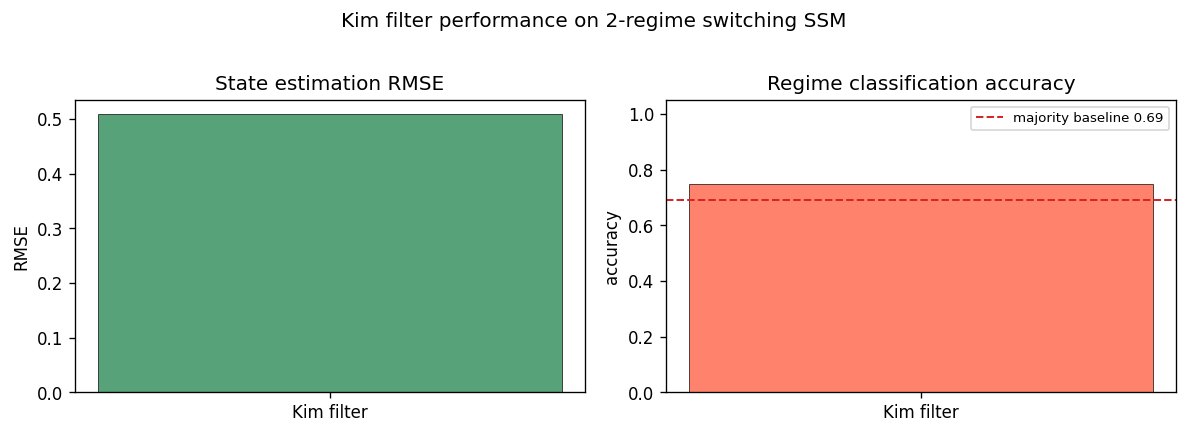

In [ ]:
# ── Kim filter accuracy ───────────────────────────────────────────────────────
x_true_rs   = states_rs[:, 0]
rmse_kim    = rmse(x_true_rs, filtered_means_km[:, 0])
regime_pred = (filtered_probs_km[:, 1] > 0.5).astype(int)
acc_kim     = float(np.mean(regime_pred == regimes_rs))

tp = int(np.sum((regime_pred == 1) & (regimes_rs == 1)))
tn = int(np.sum((regime_pred == 0) & (regimes_rs == 0)))
fp = int(np.sum((regime_pred == 1) & (regimes_rs == 0)))
fn = int(np.sum((regime_pred == 0) & (regimes_rs == 1)))
prec = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
rec  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')

print(f"State estimation RMSE:          {rmse_kim:.4f}")
print(f"Regime classification accuracy: {acc_kim:.3f}")
print(f"\nConfusion matrix (predicted \\ true):")
print(f"              true-0   true-1")
print(f"  pred-0      {tn:5d}    {fn:5d}")
print(f"  pred-1      {fp:5d}    {tp:5d}")
print(f"  Precision: {prec:.3f}   Recall: {rec:.3f}")

# ── summary plot ──────────────────────────────────────────────────────────────
baseline = max((regimes_rs == 0).mean(), (regimes_rs == 1).mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(['Kim filter'], [rmse_kim], color='seagreen', alpha=0.8,
            edgecolor='k', linewidth=0.5)
axes[0].set_ylabel('RMSE')
axes[0].set_title('State estimation RMSE')

axes[1].bar(['Kim filter'], [acc_kim], color='tomato', alpha=0.8,
            edgecolor='k', linewidth=0.5)
axes[1].axhline(baseline, color='C3', ls='--', lw=1.2,
                label=f'majority baseline {baseline:.2f}')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('accuracy')
axes[1].set_title('Regime classification accuracy')
axes[1].legend(fontsize=8)

plt.suptitle('Kim filter performance on 2-regime switching SSM', y=1.02)
plt.tight_layout()
plt.show()

---
## Next steps

- **MLE for LinearARMASSM**: the ARMA latent structure admits an exact Kalman filter (via the state-space augmentation already implemented), enabling KF MLE for ARMA parameters as a baseline for the misspecification diagnostics in Section 6
- **RBPF PMMH**: Rao-Blackwellized particle filter analytically marginalizes the continuous state, reducing Monte Carlo variance and enabling more efficient PMMH for regime-switching models